In [54]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm
sys.path.append("/extdata4/baeklab/Hyeonseo/m6A/modformer")
from utils import utils

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

In [55]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm
sys.path.append("/extdata4/baeklab/Hyeonseo/m6A/modformer")
from utils import utils

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

## Load Data

In [56]:
hela_genomic_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif-ON0091_m6Afinal/pileup.genomic.pkl"
hela_genomic_df = pd.read_pickle(hela_genomic_df)
hela_genomic_df = hela_genomic_df[hela_genomic_df["count_all"] >= 20]
print(hela_genomic_df)

                       genome_id gene_symbol  coding  isoforms      pm6a  \
genome_id                                                                  
chr10:+:1000681  chr10:+:1000681      GTPBP4    True         1  0.018456   
chr10:+:1000683  chr10:+:1000683      GTPBP4    True         1 -0.000000   
chr10:+:1000685  chr10:+:1000685      GTPBP4    True         1  0.012951   
chr10:+:1000694  chr10:+:1000694      GTPBP4    True         1 -0.000000   
chr10:+:1000701  chr10:+:1000701      GTPBP4    True         1  0.012672   
...                          ...         ...     ...       ...       ...   
chrX:-:8732088    chrX:-:8732088       ANOS1    True         1 -0.000000   
chrX:-:8732091    chrX:-:8732091       ANOS1    True         1  0.066159   
chrX:-:8732104    chrX:-:8732104       ANOS1    True         1 -0.000000   
chrX:-:8732109    chrX:-:8732109       ANOS1    True         1 -0.000000   
chrX:-:8732112    chrX:-:8732112       ANOS1    True         1 -0.000000   

           

In [57]:
hek_genomic_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif-ON0090_m6Afinal/pileup.genomic.pkl"
hek_genomic_df = pd.read_pickle(hek_genomic_df)
hek_genomic_df = hek_genomic_df[hek_genomic_df["count_all"] >= 20]
print(hek_genomic_df)

                       genome_id gene_symbol  coding  isoforms      pm6a  \
genome_id                                                                  
chr10:+:1000681  chr10:+:1000681      GTPBP4    True         1  0.009356   
chr10:+:1000683  chr10:+:1000683      GTPBP4    True         1 -0.000000   
chr10:+:1000685  chr10:+:1000685      GTPBP4    True         1  0.007684   
chr10:+:1000694  chr10:+:1000694      GTPBP4    True         1 -0.000000   
chr10:+:1000701  chr10:+:1000701      GTPBP4    True         1  0.007402   
...                          ...         ...     ...       ...       ...   
chrX:-:8732088    chrX:-:8732088       ANOS1    True         1 -0.000000   
chrX:-:8732091    chrX:-:8732091       ANOS1    True         1  0.000000   
chrX:-:8732104    chrX:-:8732104       ANOS1    True         1  0.050544   
chrX:-:8732109    chrX:-:8732109       ANOS1    True         1  0.000000   
chrX:-:8732112    chrX:-:8732112       ANOS1    True         1  0.039708   

           

In [58]:
hela_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif-ON0091_m6Afinal/pileup.npz"
with np.load(hela_df, allow_pickle=True) as data:
    hela_df = pd.DataFrame({key: data[key] for key in data.keys()})
hela_df = hela_df[hela_df["count_all"] >= 20]
print(hela_df)

                label_id  pm6a       dom  count_all  count_pos  kl_div_neg  \
0         NM_000016:1000   0.0  0.000000        310          0  305.899872   
1         NM_000016:1008  -0.0  0.002034        310          0  306.057770   
2         NM_000016:1009  -0.0  0.000533        311          0  304.085480   
3         NM_000016:1010  -0.0  0.000452        313          0  302.496002   
4         NM_000016:1014  -0.0  0.002279        312          0  297.993103   
...                  ...   ...       ...        ...        ...         ...   
26478388   NR_184306:966   0.0  0.000000         20          0   17.596651   
26478389   NR_184306:967   0.0  0.000000         20          0   17.002420   
26478391   NR_184306:979  -0.0  0.056186         20          0   14.193596   
26478392    NR_184306:98  -0.0  0.069770         28          0   16.262259   
26478393   NR_184306:984  -0.0  0.004761         20          0   18.641640   

          kl_div_pos  logsum_1_p_pos  
0           0.000000    

In [73]:
df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif-ON0090_m6Afinal/pileup.npz"
with np.load(df, allow_pickle=True) as data:
    df = pd.DataFrame({key: data[key] for key in data.keys()})
print(df["count_all"].sum())

2804663201


In [74]:
df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-m6A_ON0118-20241129-120647-8-182000-token_normalise_ver161024_ON0090_m6Afinal/pileup_strid.npz"
with np.load(df, allow_pickle=True) as data:
    df = pd.DataFrame({key: data[key] for key in data.keys()})
print(df["count_all"].sum())

2816467429


In [75]:
df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-m6A_ON0118-20241125-221455-22-492000-token_normalise_ver161024_ON0090_m6Afinal/pileup_strid.npz"
with np.load(df, allow_pickle=True) as data:
    df = pd.DataFrame({key: data[key] for key in data.keys()})
print(df["count_all"].sum())

2816467429


In [59]:
hek_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif-ON0090_m6Afinal/pileup.npz"
with np.load(hek_df, allow_pickle=True) as data:
    hek_df = pd.DataFrame({key: data[key] for key in data.keys()})
hek_df = hek_df[hek_df["count_all"] >= 20]
print(hek_df)

                label_id      pm6a           dom  count_all  count_pos  \
0         NM_000016:1000  0.000000  0.000000e+00        258          0   
1         NM_000016:1008 -0.000000  7.130211e-05        257          0   
2         NM_000016:1009 -0.000000  1.760241e-03        260          0   
3         NM_000016:1010 -0.000000  1.158481e-03        263          0   
4         NM_000016:1014 -0.000000  1.866647e-07        258          0   
...                  ...       ...           ...        ...        ...   
30894417    NR_184306:85  0.000000  0.000000e+00         51          0   
30894420    NR_184306:87  0.094081  3.562228e-02         51          1   
30894423    NR_184306:88 -0.000000  3.432852e-03         51          0   
30894435    NR_184306:93  1.945571  6.774195e-01         50         23   
30894446    NR_184306:98  0.000000  0.000000e+00         48          0   

          kl_div_neg  kl_div_pos  logsum_1_p_pos  
0         254.803940    0.000000        0.000000  
1        

In [60]:
hek_label = pd.read_pickle(
    "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/label/BaeklabFinal.Genome.v2Genomic.GP3.depth5_None.twm6astrict.agg.all5mer.pkl")
hela_label = pd.read_pickle(
    "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0091/ON0091/label/BaeklabFinal.eTAM..v2Genomic.GP3.depth5_None.twm6astrict.agg.all5mer.pkl")

In [61]:
hek_transcript_label = pd.read_pickle(
    "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/label/BaeklabFinal.Genome.v2Genomic.GP3.depth5_None.twm6astrict.pkl")
hela_transcript_label = pd.read_pickle(
    "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0091/ON0091/label/BaeklabFinal.eTAM..v2Genomic.GP3.depth5_None.twm6astrict.pkl")

In [62]:
hek_dorado_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/dorado-070-aligned/intermediates/dorado_output.pkl.m6A.genomic.pkl")
print(hek_dorado_df)

                       genome_id gene_symbol       dom  count_dom  coding
genome_id                                                                
chr10:+:1000680  chr10:+:1000680      GTPBP4  0.142857          7    True
chr10:+:1000681  chr10:+:1000681      GTPBP4  0.004219        474    True
chr10:+:1000683  chr10:+:1000683      GTPBP4  0.004073        491    True
chr10:+:1000685  chr10:+:1000685      GTPBP4  0.017167        466    True
chr10:+:1000688  chr10:+:1000688      GTPBP4  1.000000          1    True
...                          ...         ...       ...        ...     ...
chrX:-:9760794    chrX:-:9760794      GPR143  0.000000          5    True
chrX:-:9760797    chrX:-:9760797      GPR143  0.000000          5    True
chrX:-:9760808    chrX:-:9760808      GPR143  0.250000          4    True
chrX:-:9760817    chrX:-:9760817      GPR143  0.000000          5    True
chrX:-:9760823    chrX:-:9760823      GPR143  0.000000          4    True

[22959784 rows x 5 columns]


In [63]:
fdr_threshold = 0.48

hela_genomic_df_m6a = hela_genomic_df[hela_genomic_df["pm6a"] > fdr_threshold].copy()
hek_genomic_df_m6a = hek_genomic_df[hek_genomic_df["pm6a"] > fdr_threshold].copy()

In [64]:
dorado_f1_threshold = 0.46

airna_arr = hek_genomic_df[(hek_genomic_df["pm6a"] >= fdr_threshold) & (hek_genomic_df["count_all"] >= 20)]["genome_id"].unique()
dorado_arr = hek_dorado_df[(hek_dorado_df["dom"] >= dorado_f1_threshold) & (hek_dorado_df["count_dom"] >= 20)]["genome_id"].unique()

## Venn

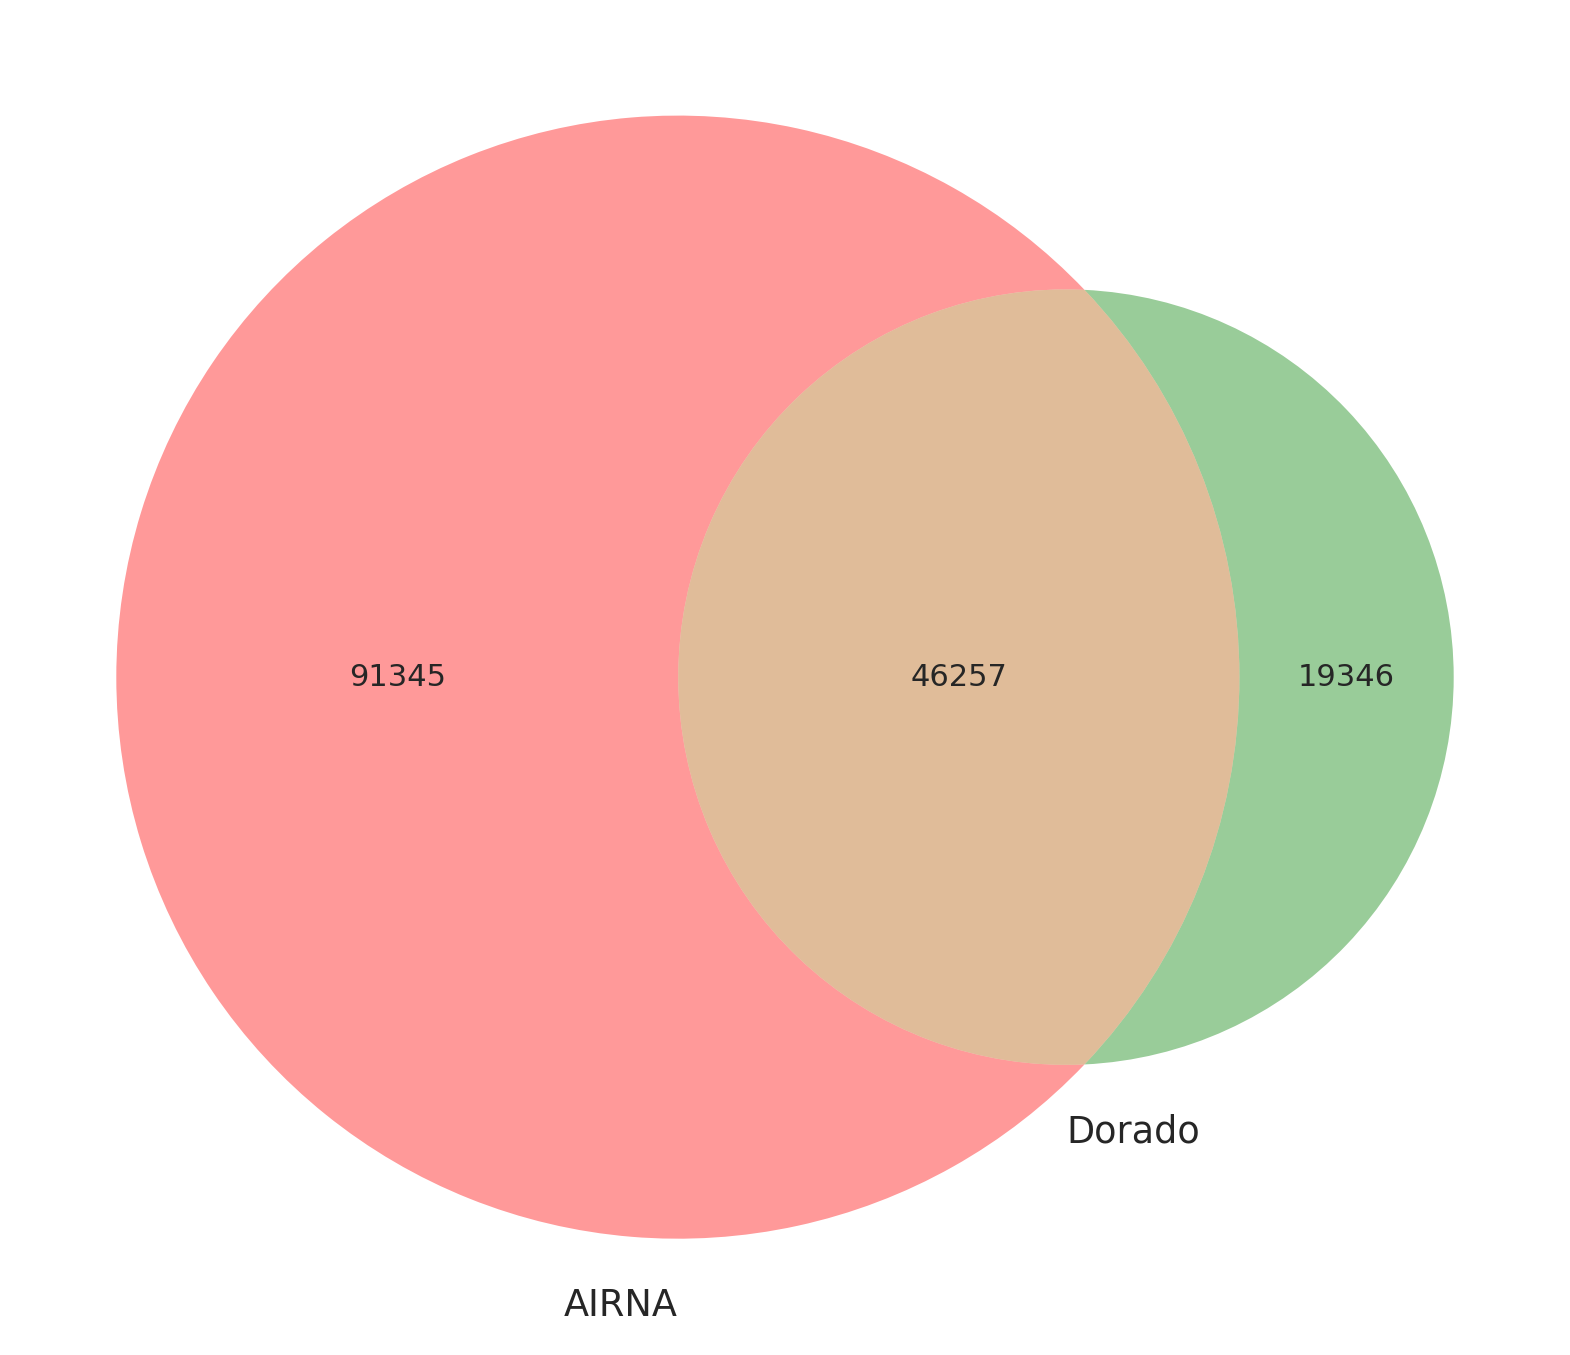

In [65]:
## Plot Venn
import matplotlib_venn as venn
fig, ax = plt.subplots(1, 1, figsize=(20, 20))
## count
venn.venn2([set(airna_arr), set(dorado_arr)], set_labels=("AIRNA", "Dorado"))

plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/venn.pdf", format="pdf")
plt.show()


## Pie

In [66]:
hek_eval = hek_genomic_df_m6a.reset_index(drop=True).merge(hek_label, on="genome_id", how="left")
hela_eval = hela_genomic_df_m6a.reset_index(drop=True).merge(hela_label, on="genome_id", how="left")

In [67]:
print(hek_eval[hek_eval["depth"] < hek_eval["count_all"]])

               genome_id gene_symbol  coding  isoforms      pm6a       dom  \
2216    chr10:+:78035710       RPS24    True         6  1.113634  0.300152   
8461    chr11:+:75405703        RPS3    True         2  1.258650  0.293670   
8729     chr11:+:8688205      RPL27A    True         1  0.546967  0.114401   
8730     chr11:+:8688210      RPL27A    True         1  0.758280  0.179161   
8731     chr11:+:8688419      RPL27A    True         1  0.881178  0.285976   
...                  ...         ...     ...       ...       ...       ...   
118467   chr7:+:44802763        PPIA    True         2  0.643504  0.126195   
122493    chr7:-:5527532        ACTB    True         1  2.485489  0.631661   
122494    chr7:-:5527601        ACTB    True         1  0.537065  0.097676   
122495    chr7:-:5527742        ACTB    True         1  2.564684  0.584899   
122496    chr7:-:5528621        ACTB    True         1  1.079498  0.278988   

        count_all  logsum_1_p_pos   kl_div_pos    kl_div_neg   

In [71]:
print(hek_eval[hek_eval["genome_id"]=="chr10:+:100983457"])

            genome_id gene_symbol  coding  isoforms    pm6a       dom  \
60  chr10:+:100983457      SEMA4G    True         6  0.5451  0.140307   

    count_all  logsum_1_p_pos  kl_div_pos  kl_div_neg   5mer  drach  \
60         95      -28.698055   11.202072    68.63755  GGACG  False   

    m6A_level  label  depth  
60   0.210874     -1     95  


In [14]:
print(len(hek_eval), len(hela_eval))

137602 118086


114231 6709 15458 1204
[0.83015508 0.04875656 0.11233848 0.00874987]


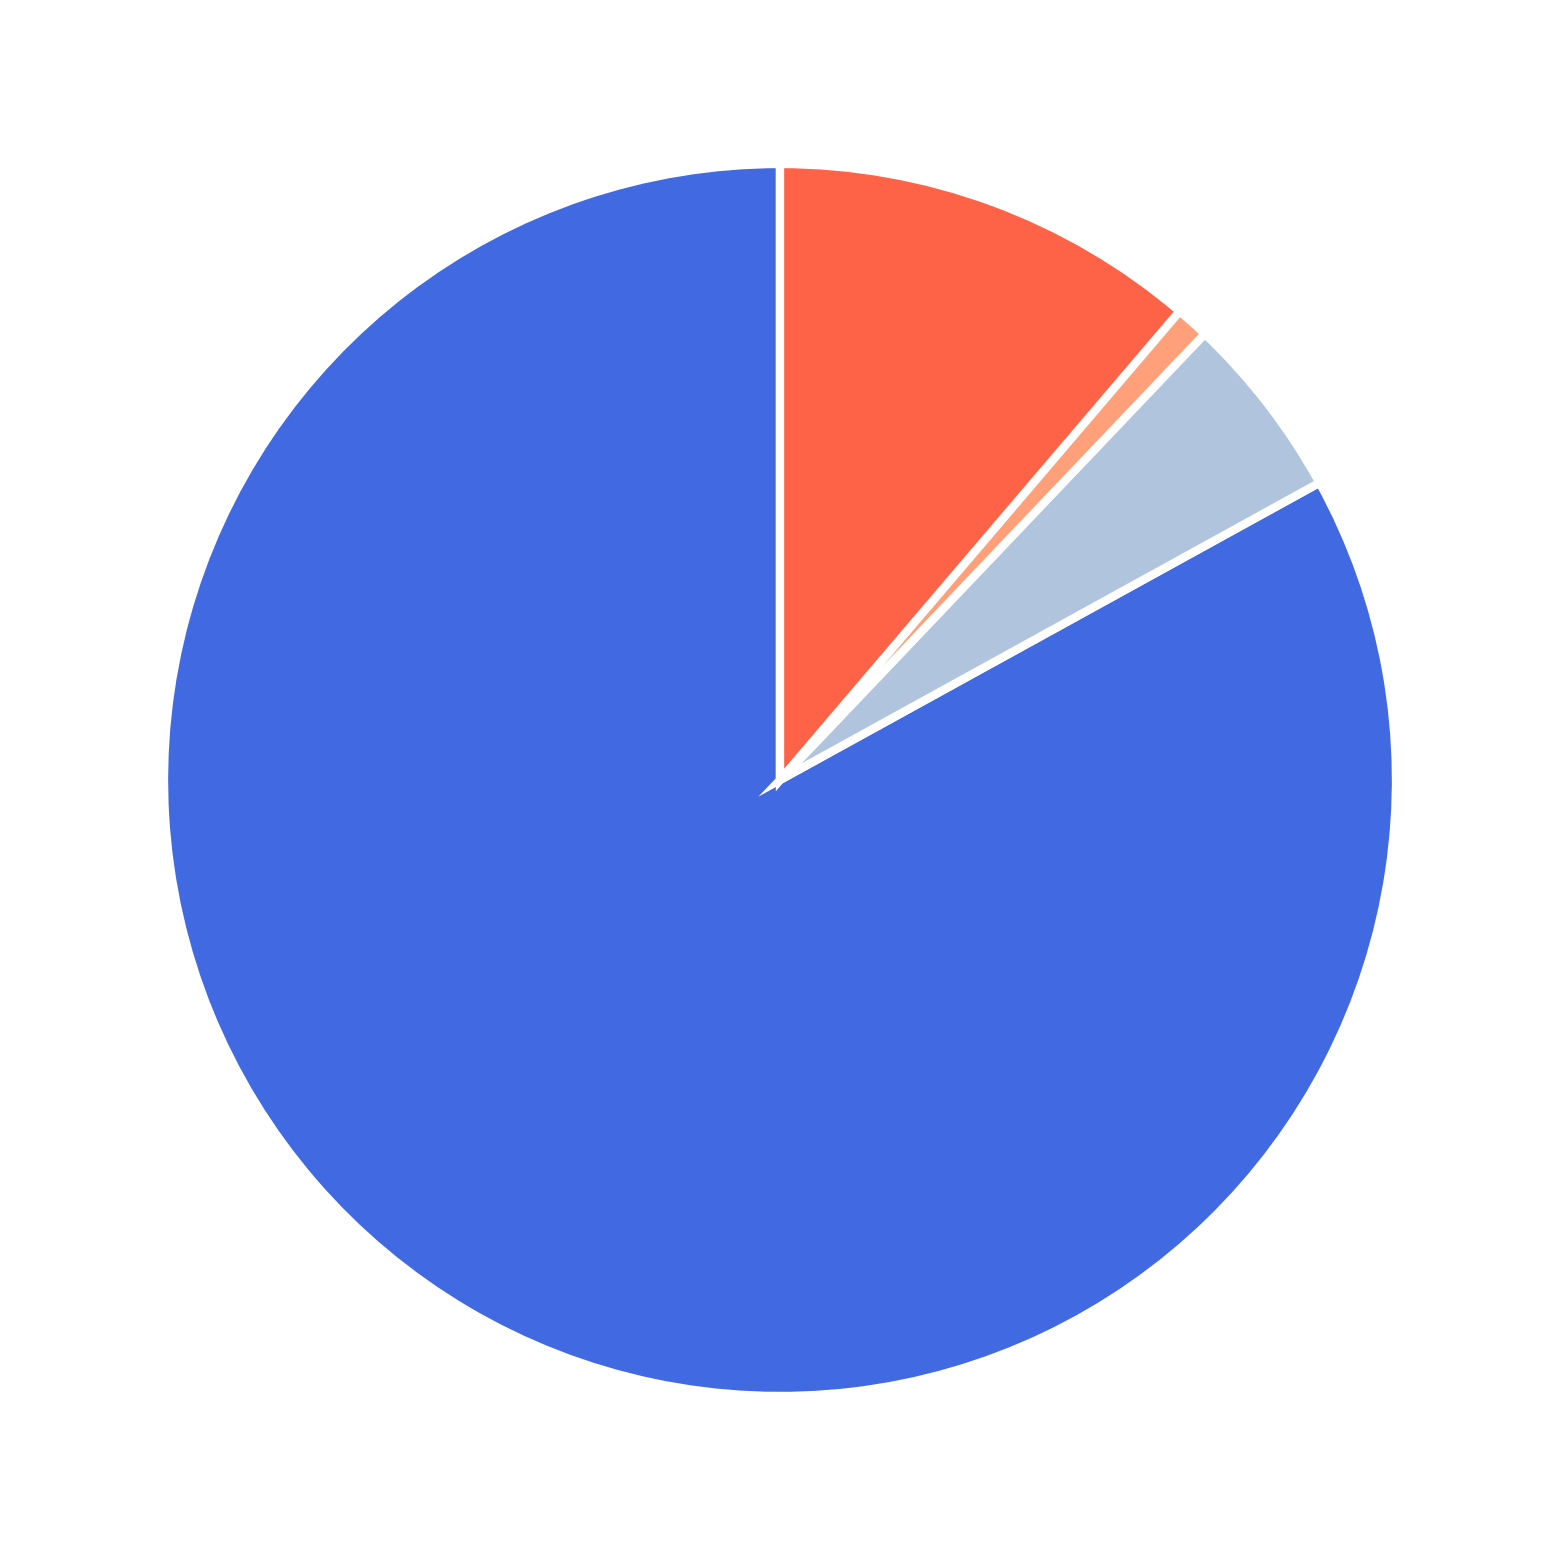

In [15]:
m6a_df = hek_eval
drach_coding = len(m6a_df[(m6a_df["drach"]) & (m6a_df["coding"])])
drach_noncoding = len(m6a_df[(m6a_df["drach"]) & (~m6a_df["coding"])])
non_drach_coding = len(m6a_df[(~m6a_df["drach"]) & (m6a_df["coding"])])
non_drach_noncoding = len(m6a_df[(~m6a_df["drach"]) & (~m6a_df["coding"])])

print(drach_coding, drach_noncoding, non_drach_coding, non_drach_noncoding)
print(np.array([drach_coding, drach_noncoding, non_drach_coding, non_drach_noncoding, ])/len(m6a_df))

fig, ax = plt.subplots(1, 1, figsize=(20, 20))
y = [drach_coding, drach_noncoding, non_drach_noncoding, non_drach_coding, ]
plt.rcParams.update({'font.size': 32, 'lines.linewidth': 6})
wp = {'linewidth': 6, 'edgecolor':'white'}
colors = ['royalblue', 'lightsteelblue', 'lightsalmon', 'tomato', ]
plt.pie(y,startangle = 90, colors=colors, wedgeprops=wp)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/pie_HEK.pdf", format="pdf")
plt.show()


98277 5495 13297 1017
[0.83224938 0.04653388 0.11260437 0.00861237]


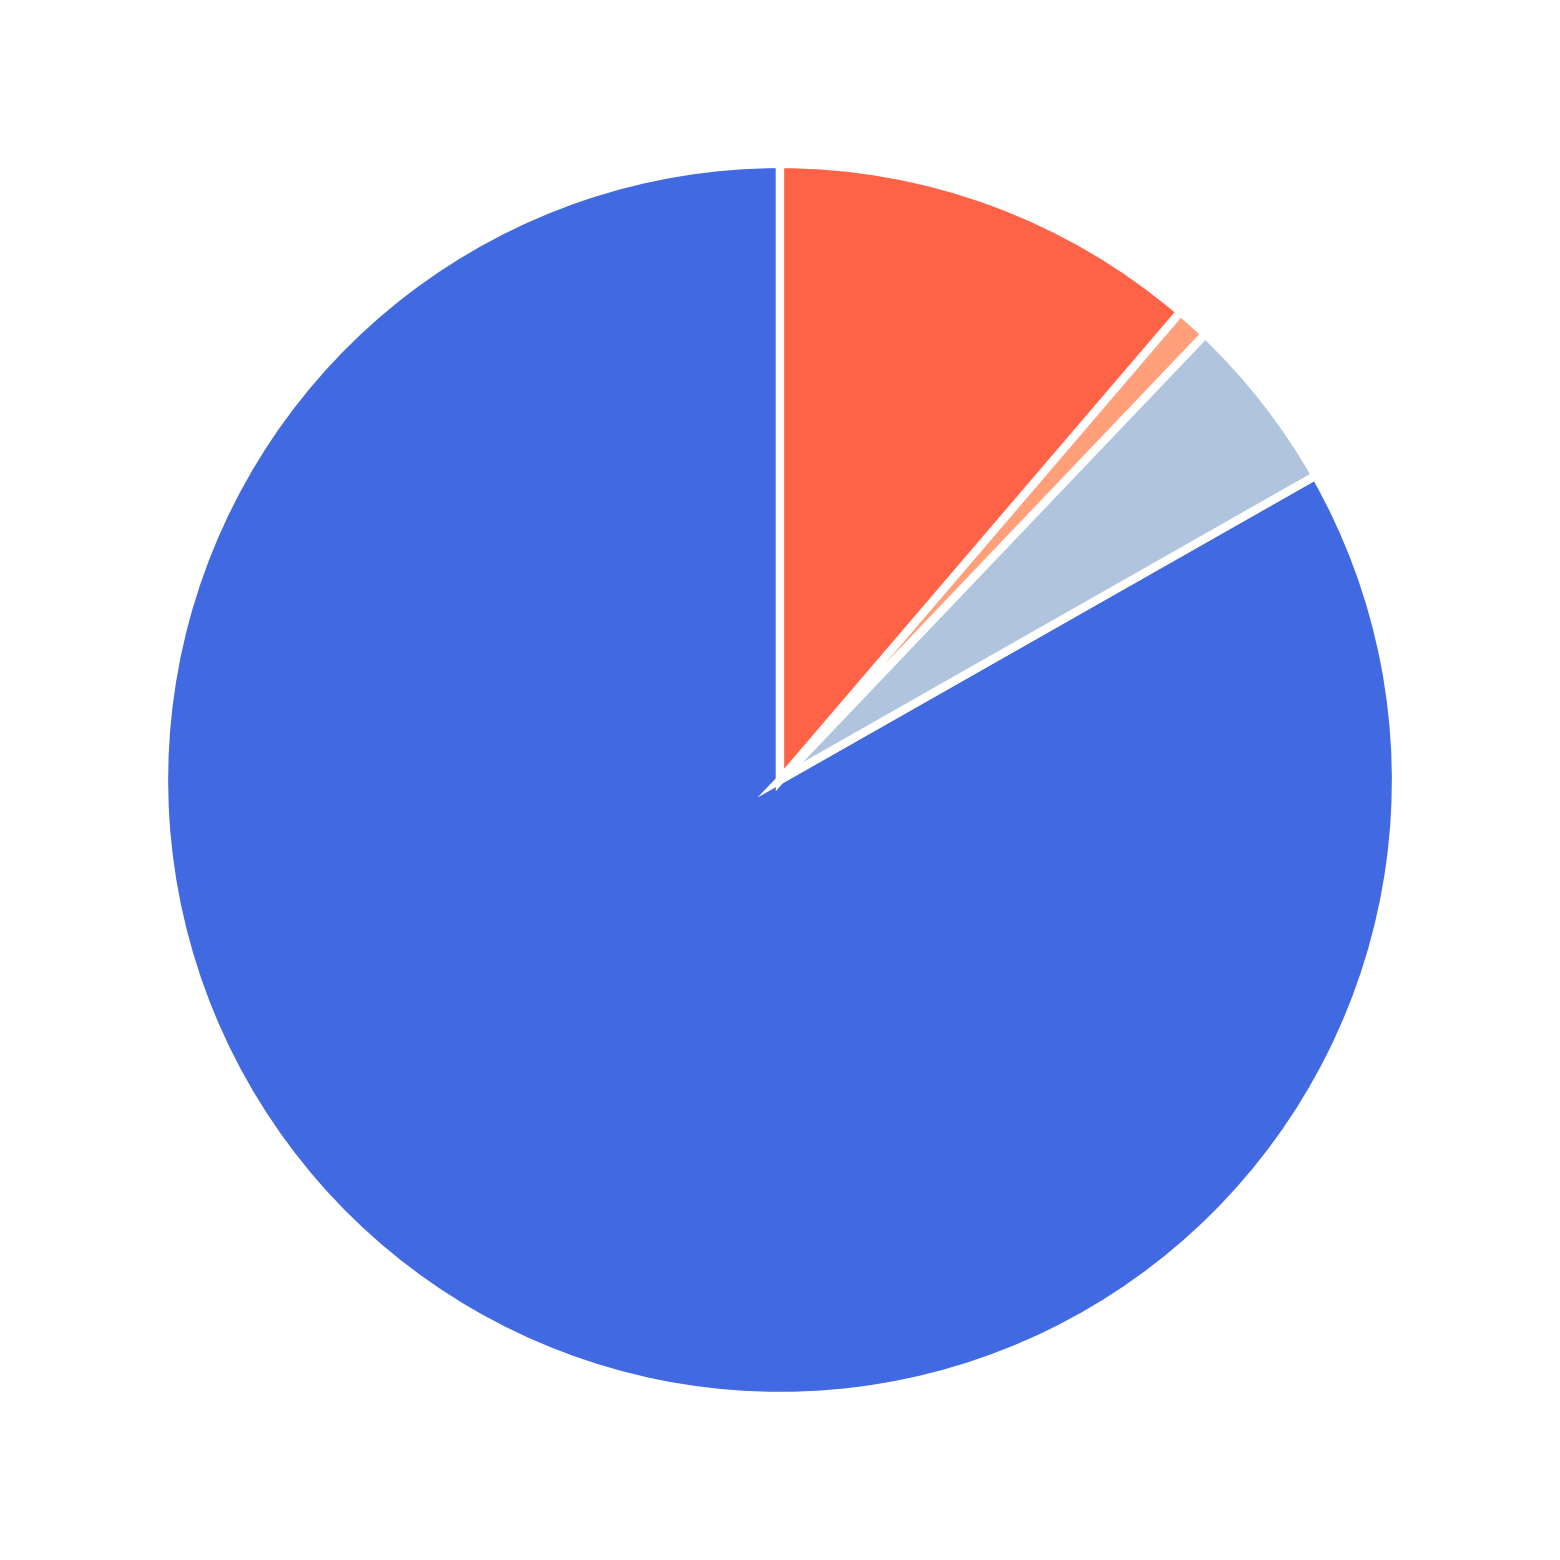

In [16]:
m6a_df = hela_eval
drach_coding = len(m6a_df[(m6a_df["drach"]) & (m6a_df["coding"])])
drach_noncoding = len(m6a_df[(m6a_df["drach"]) & (~m6a_df["coding"])])
non_drach_coding = len(m6a_df[(~m6a_df["drach"]) & (m6a_df["coding"])])
non_drach_noncoding = len(m6a_df[(~m6a_df["drach"]) & (~m6a_df["coding"])])

print(drach_coding, drach_noncoding, non_drach_coding, non_drach_noncoding)
print(np.array([drach_coding, drach_noncoding, non_drach_coding, non_drach_noncoding, ])/len(m6a_df))

fig, ax = plt.subplots(1, 1, figsize=(20, 20))
y = [drach_coding, drach_noncoding, non_drach_noncoding, non_drach_coding, ]
plt.rcParams.update({'font.size': 32, 'lines.linewidth': 6})
wp = {'linewidth': 6, 'edgecolor':'white'}
colors = ['royalblue', 'lightsteelblue', 'lightsalmon', 'tomato', ]
plt.pie(y,startangle = 90, colors=colors, wedgeprops=wp)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/pie_HeLa.pdf", format="pdf")
plt.show()
        

## 5mer motif

In [17]:
hek_eval_5mer = hek_eval.copy()
hek_eval_5mer["5mer"] = hek_eval_5mer["5mer"].str.split(":")
hek_eval_5mer = hek_eval_5mer.explode("5mer")
print(hek_eval_5mer)

                genome_id gene_symbol  coding  isoforms      pm6a       dom  \
0       chr10:+:100347295         SCD    True         1  0.499425  0.090856   
1       chr10:+:100360903         SCD    True         1  0.541704  0.094596   
2       chr10:+:100361573         SCD    True         1  0.504196  0.111480   
3       chr10:+:100363097         SCD    True         1  0.694696  0.164417   
4       chr10:+:100363423         SCD    True         1  0.714304  0.238482   
...                   ...         ...     ...       ...       ...       ...   
137597    chrX:-:85864735         CHM    True         2  0.505544  0.164515   
137598    chrX:-:85956342         CHM    True         1  0.956683  0.195457   
137599    chrX:-:85971260         CHM    True         1  2.008692  0.521283   
137600    chrX:-:85971275         CHM    True         1  0.485441  0.130404   
137601    chrX:-:85971360         CHM    True         1  0.591708  0.181219   

        count_all  logsum_1_p_pos  kl_div_pos   kl_

In [18]:
hela_eval_5mer = hela_eval.copy()
hela_eval_5mer["5mer"] = hela_eval_5mer["5mer"].str.split(":")
hela_eval_5mer = hela_eval_5mer.explode("5mer")
print(hela_eval_5mer)

                genome_id gene_symbol  coding  isoforms      pm6a       dom  \
0       chr10:+:100360903         SCD    True         1  0.528944  0.088089   
1       chr10:+:100363097         SCD    True         1  0.586329  0.129775   
2       chr10:+:100363423         SCD    True         1  0.689704  0.207958   
3       chr10:+:100364038         SCD    True         1  0.489546  0.095135   
4       chr10:+:100364512         SCD    True         1  1.574561  0.307121   
...                   ...         ...     ...       ...       ...       ...   
118081    chrX:-:85963894         CHM    True         1  0.496800  0.105395   
118082    chrX:-:85963898         CHM    True         1  0.556856  0.103919   
118083    chrX:-:85971282         CHM    True         1  0.542678  0.095033   
118084    chrX:-:85971349         CHM    True         1  0.619062  0.133625   
118085    chrX:-:85971360         CHM    True         1  0.742302  0.239461   

        count_all  logsum_1_p_pos   kl_div_pos   kl

In [19]:
def drach_ed(seq):
    ed = 0
    if not seq[0] in ["A", "G", "T", "U"]:
        ed += 1
    if not seq[1] in ["G", "A"]:
        ed += 1
    if not seq[2] == "A":
        ed += 1
    if not seq[3] == "C":
        ed += 1
    if not seq[4] in ["A", "C", "T", "U"]:
        ed += 1
    return ed


In [20]:
hek_eval_5mer["drach_ed"] = hek_eval_5mer["5mer"].apply(drach_ed)
print(hek_eval_5mer)

                genome_id gene_symbol  coding  isoforms      pm6a       dom  \
0       chr10:+:100347295         SCD    True         1  0.499425  0.090856   
1       chr10:+:100360903         SCD    True         1  0.541704  0.094596   
2       chr10:+:100361573         SCD    True         1  0.504196  0.111480   
3       chr10:+:100363097         SCD    True         1  0.694696  0.164417   
4       chr10:+:100363423         SCD    True         1  0.714304  0.238482   
...                   ...         ...     ...       ...       ...       ...   
137597    chrX:-:85864735         CHM    True         2  0.505544  0.164515   
137598    chrX:-:85956342         CHM    True         1  0.956683  0.195457   
137599    chrX:-:85971260         CHM    True         1  2.008692  0.521283   
137600    chrX:-:85971275         CHM    True         1  0.485441  0.130404   
137601    chrX:-:85971360         CHM    True         1  0.591708  0.181219   

        count_all  logsum_1_p_pos  kl_div_pos   kl_

In [21]:
print(hek_eval_5mer["drach_ed"].value_counts())

drach_ed
0    120946
1     15790
2       676
3       222
4        62
Name: count, dtype: int64


In [22]:
print(hek_eval_5mer[hek_eval_5mer["drach_ed"] == 4]["5mer"].value_counts())

5mer
CCATG    32
CCAGG    15
CCAAG     8
CTATG     4
CTAAG     2
CTAGG     1
Name: count, dtype: int64


In [23]:
import re

     5mer  count
0   GGACT  20104
1   GGACA  16244
2   AGACT  13828
3   GAACT  13668
4   GGACC  11431
5   TGACT   9814
6   AAACT   8788
7   AGACA   6570
8   GAACA   5583
9   GGACG   4427
10  AGACC   3257
11  GAACC   2815
12  TGACA   2770
13  GGATT   2530
14  TAACT   2199
15  AAACA   1718
16  GTACT   1185
17  TGACC   1087
18  AGACG   1054
19  AAACC    798


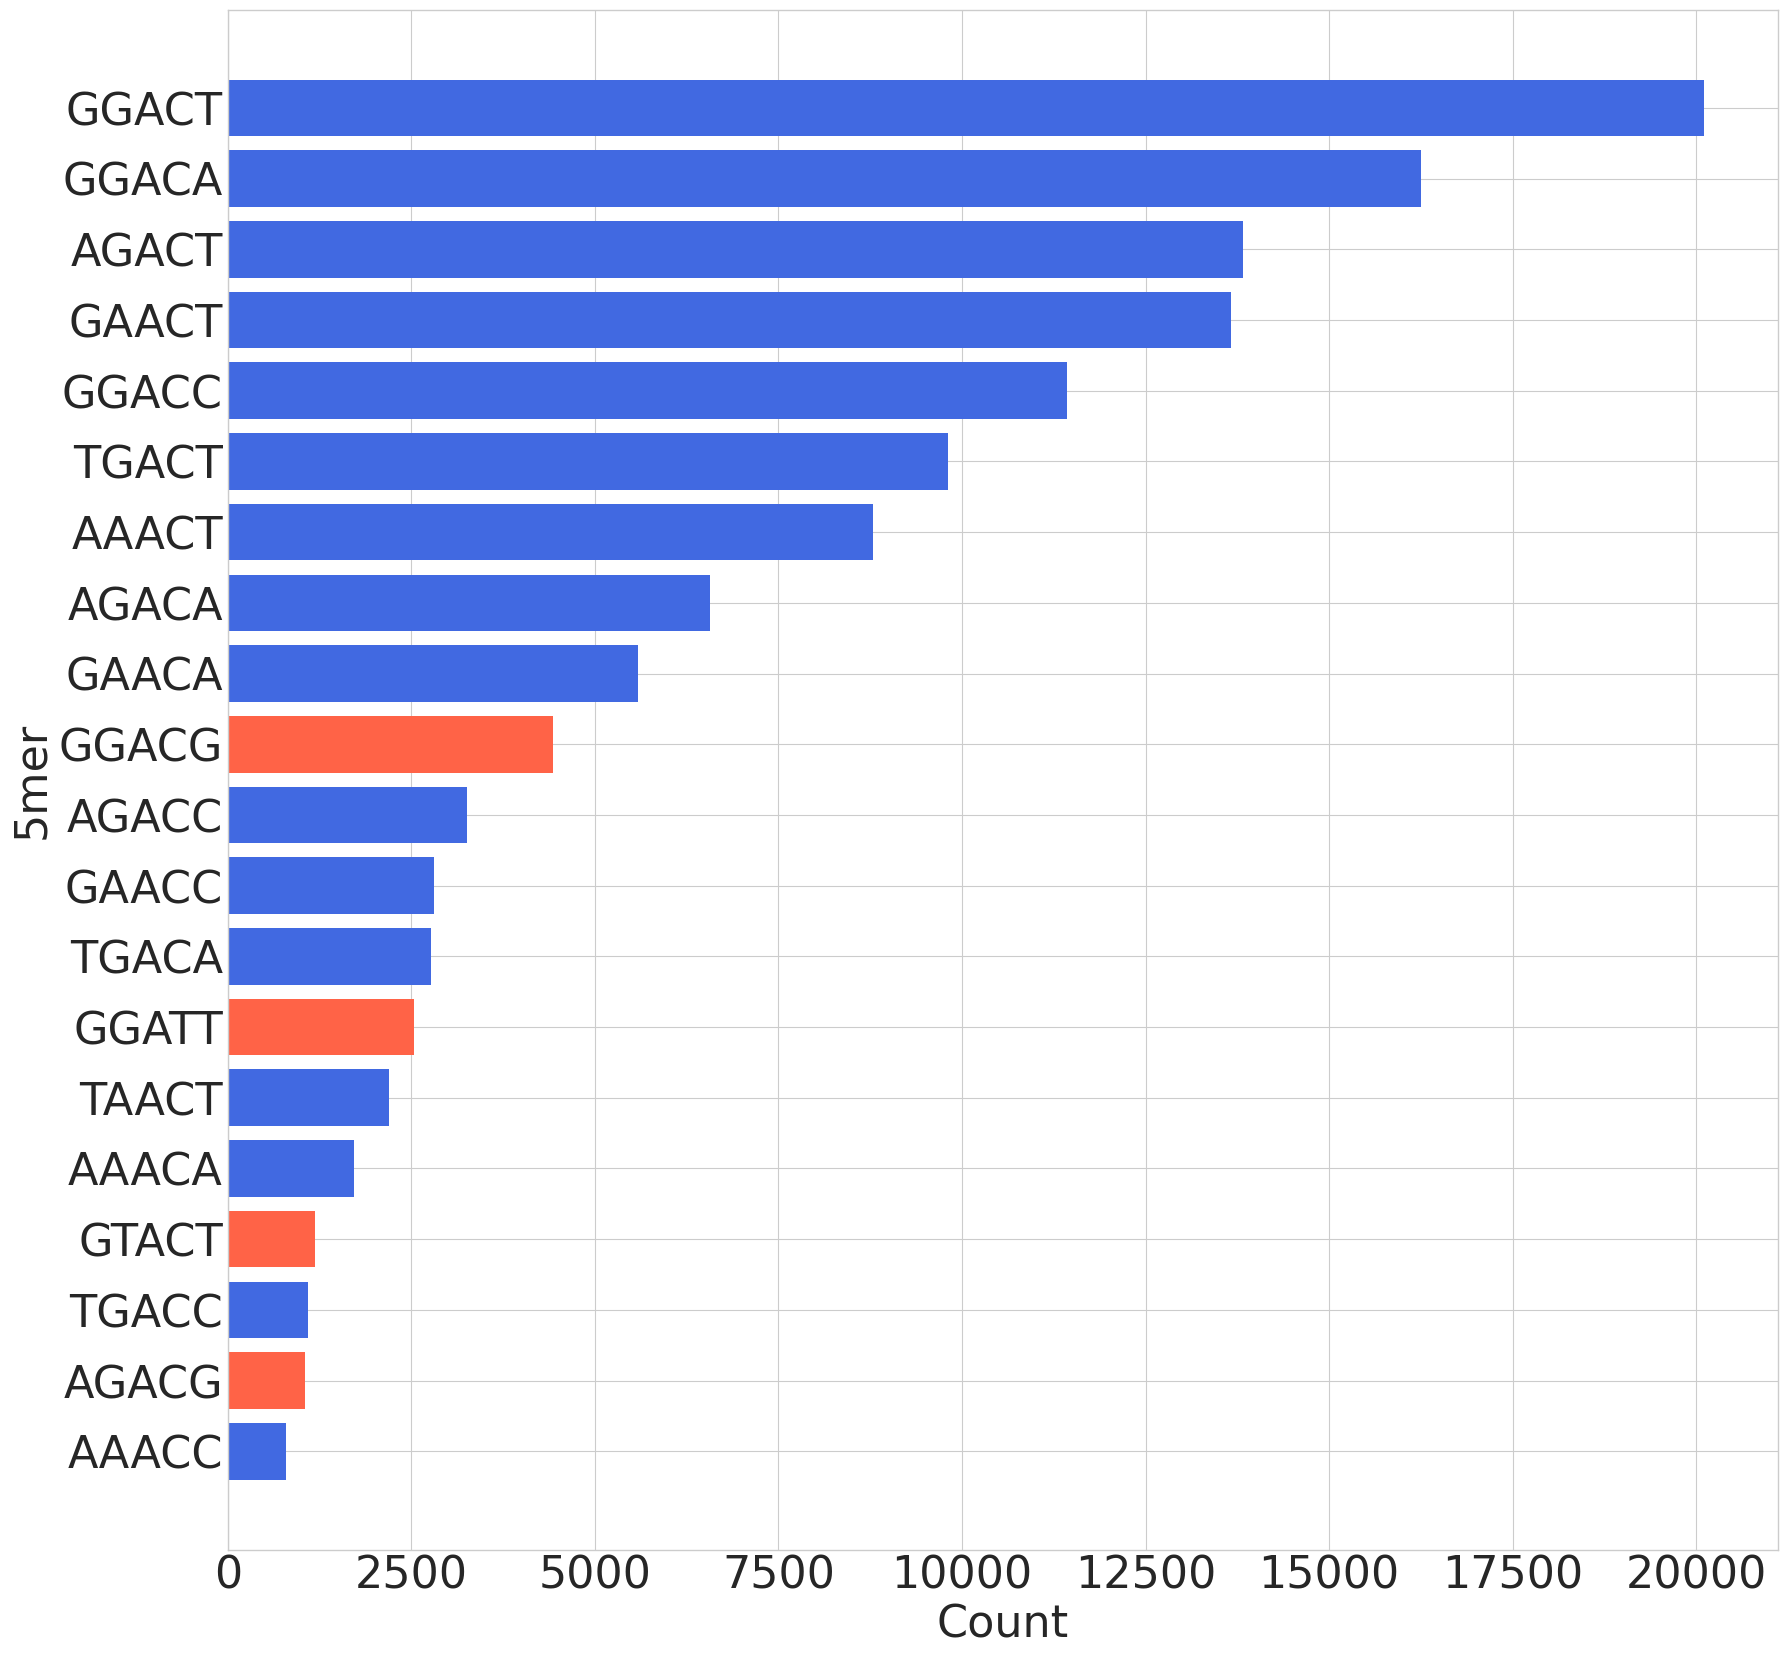

In [24]:
## Plot Top 20 5mers


df = hek_eval_5mer
def is_drach(seq):
    seq = seq.upper()
    if re.search(r'[AGUT][AG]AC[ACUT]', seq):
        return True
    else:
        return False

fig, ax = plt.subplots(1, 1, figsize=(20, 20))
count_5mers = df["5mer"].value_counts().head(20)

## Color by DRACH: True: Royalblue, False: Tomato
## use is_drach function
count_5mers = count_5mers.reset_index()

print(count_5mers)
count_5mers["drach"] = count_5mers["5mer"].apply(is_drach)
count_5mers["color"] = count_5mers["drach"].map({True: "royalblue", False: "tomato"})
count_5mers.sort_values("count", inplace=True)
ax.barh(count_5mers["5mer"], count_5mers["count"], color=count_5mers["color"])
ax.set_xlabel("Count")
ax.set_ylabel("5mer")
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/top20_5mers_hek.pdf", format="pdf")
plt.show()

     5mer  count
0   GGACT  17210
1   GGACA  13956
2   AGACT  11933
3   GAACT  11765
4   GGACC   9805
5   TGACT   8569
6   AAACT   7351
7   AGACA   5553
8   GAACA   4696
9   GGACG   3616
10  AGACC   2811
11  GAACC   2572
12  TGACA   2387
13  GGATT   2181
14  TAACT   1879
15  AAACA   1468
16  GTACT   1077
17  TGACC    977
18  AGACG    906
19  CAACT    677


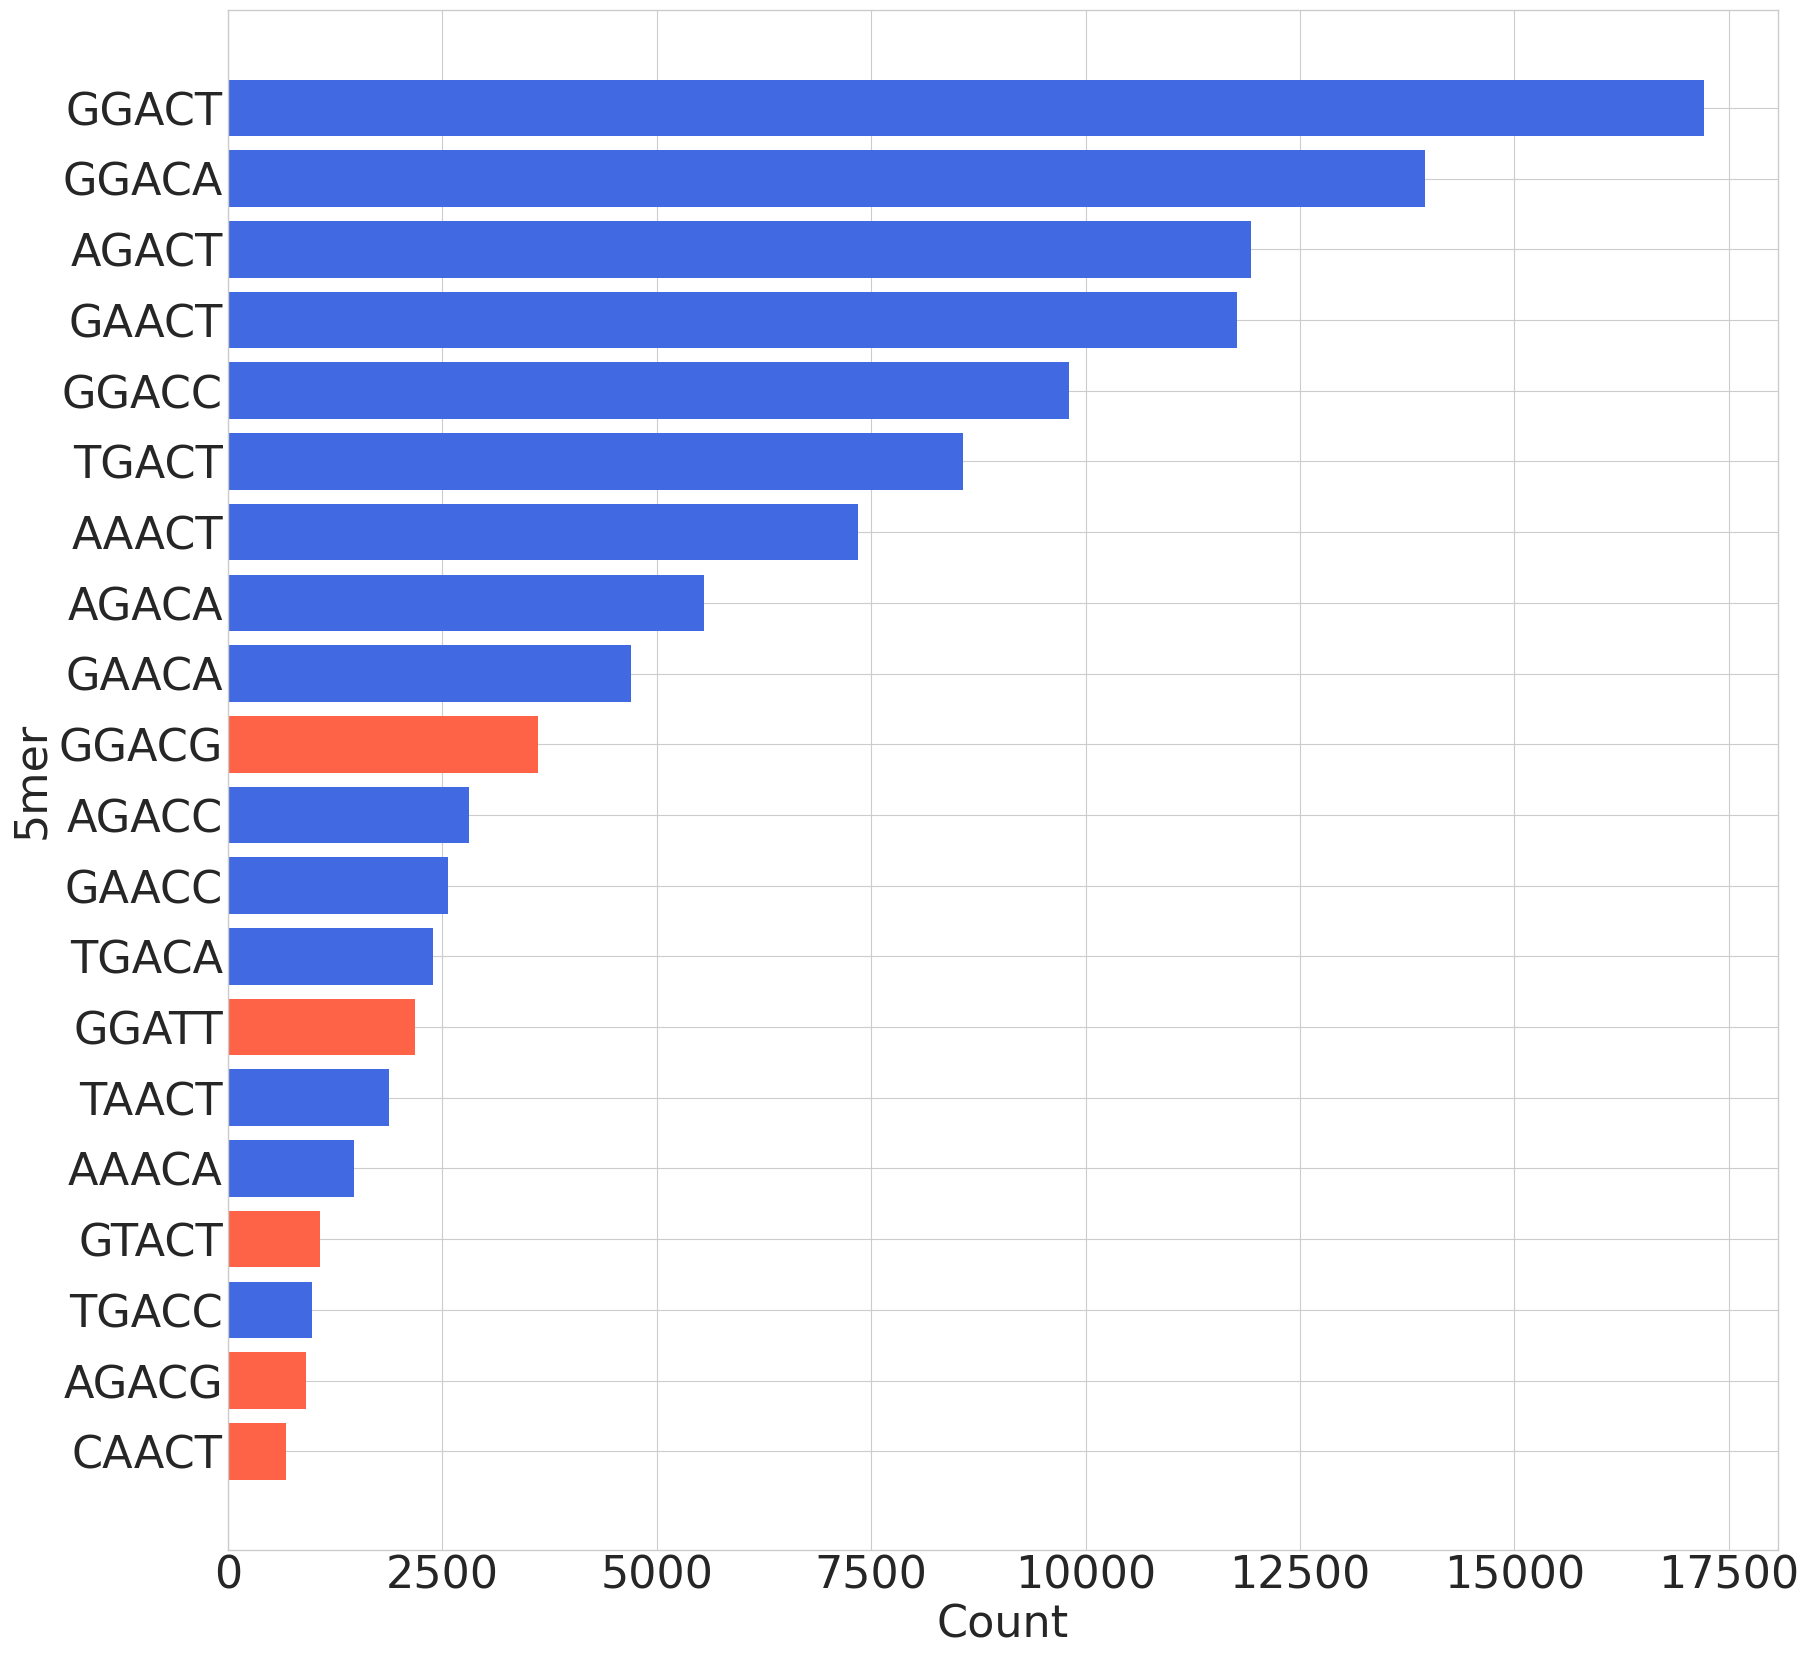

In [25]:
## Plot Top 20 5mers

df = hela_eval_5mer
def is_drach(seq):
    seq = seq.upper()
    if re.search(r'[AGUT][AG]AC[ACUT]', seq):
        return True
    else:
        return False

fig, ax = plt.subplots(1, 1, figsize=(20, 20))
count_5mers = df["5mer"].value_counts().head(20)

## Color by DRACH: True: Royalblue, False: Tomato
## use is_drach function
count_5mers = count_5mers.reset_index()

print(count_5mers)
count_5mers["drach"] = count_5mers["5mer"].apply(is_drach)
count_5mers["color"] = count_5mers["drach"].map({True: "royalblue", False: "tomato"})
count_5mers.sort_values("count", inplace=True)
ax.barh(count_5mers["5mer"], count_5mers["count"], color=count_5mers["color"])
ax.set_xlabel("Count")
ax.set_ylabel("5mer")
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/top20_5mers_hela.pdf", format="pdf")
plt.show()

In [26]:
import logomaker as lm
from Bio import SeqIO

In [27]:
ref_path = "/extdata4/baeklab/Hyeonseo/m6A/res/ref/isoform/hg38_rna_nrnm.fasta"
fasta_dict = SeqIO.to_dict(SeqIO.parse(ref_path, "fasta"))
fasta_dict = {x.split(".")[0]: y for x, y in fasta_dict.items()}

In [28]:
hela_m6a_transcript = hek_transcript_label.merge(hela_genomic_df_m6a[["genome_id"]].reset_index(drop=True), on="genome_id", how="inner")
hek_m6a_transcript = hek_transcript_label.merge(hek_genomic_df_m6a[["genome_id"]].reset_index(drop=True), on="genome_id", how="inner")

In [29]:
hela_m6a_transcript["9mer"] = hela_m6a_transcript.apply(lambda x: fasta_dict[x["nmid"]].seq[x["pos"]-4:x["pos"]+5], axis=1)
hek_m6a_transcript["9mer"] = hek_m6a_transcript.apply(lambda x: fasta_dict[x["nmid"]].seq[x["pos"]-4:x["pos"]+5], axis=1)

In [30]:
hela_m6a_genomic_9mer = hela_m6a_transcript.groupby("genome_id").agg({"9mer": np.unique}).reset_index()
hek_m6a_genomic_9mer = hek_m6a_transcript.groupby("genome_id").agg({"9mer": np.unique}).reset_index()

In [31]:
hela_m6a_genomic_9mer = np.concatenate(hela_m6a_genomic_9mer["9mer"].values)
hek_m6a_genomic_9mer = np.concatenate(hek_m6a_genomic_9mer["9mer"].values)

In [32]:
hela_m6a_genomic_9mer = pd.DataFrame(hela_m6a_genomic_9mer, columns=["9mer"])
hek_m6a_genomic_9mer = pd.DataFrame(hek_m6a_genomic_9mer, columns=["9mer"])

In [33]:
hela_m6a_genomic_9mer["length"] = hela_m6a_genomic_9mer["9mer"].apply(len)
hela_m6a_genomic_9mer = hela_m6a_genomic_9mer[hela_m6a_genomic_9mer["length"] == 9]
hek_m6a_genomic_9mer["length"] = hek_m6a_genomic_9mer["9mer"].apply(len)
hek_m6a_genomic_9mer = hek_m6a_genomic_9mer[hek_m6a_genomic_9mer["length"] == 9]

In [34]:
hela_m6a_genomic_9mer[list(range(9))] = hela_m6a_genomic_9mer.apply(lambda x: list(x["9mer"]), axis=1, result_type="expand")
hek_m6a_genomic_9mer[list(range(9))] = hek_m6a_genomic_9mer.apply(lambda x: list(x["9mer"]), axis=1, result_type="expand")

In [35]:
hela_logo_df = hela_m6a_genomic_9mer[list(range(9))].apply(pd.Series.value_counts).fillna(0).astype(int).T
hek_logo_df = hek_m6a_genomic_9mer[list(range(9))].apply(pd.Series.value_counts).fillna(0).astype(int).T

/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


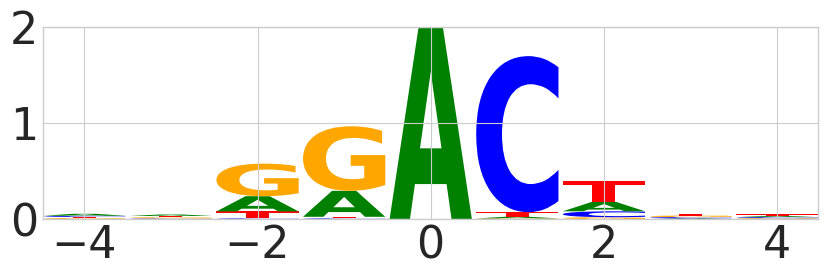

In [36]:
bit_df = hela_logo_df.copy()
bit_df.index = np.arange(9) - 4
bit_df = bit_df.apply(lambda x: x/x.sum(), axis=1)
bit_df = bit_df.apply(lambda x: x*(2+(x*np.log2(x)).sum()), axis=1)
logo = lm.Logo(bit_df.fillna(0), color_scheme="classic")
plt.xticks([-4,-2,0,2,4])
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/seqlogo_hela.pdf", format="pdf")
plt.show()


/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


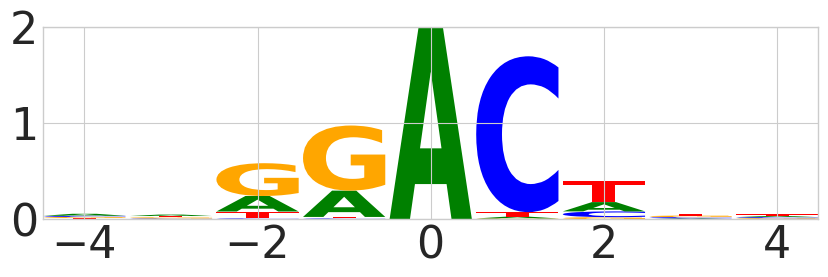

In [37]:
bit_df = hek_logo_df.copy()
bit_df.index = np.arange(9) - 4
bit_df = bit_df.apply(lambda x: x/x.sum(), axis=1)
bit_df = bit_df.apply(lambda x: x*(2+(x*np.log2(x)).sum()), axis=1)
logo = lm.Logo(bit_df.fillna(0), color_scheme="classic")
plt.xticks([-4,-2,0,2,4])
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/seqlogo_hek.pdf", format="pdf")
plt.show()


/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


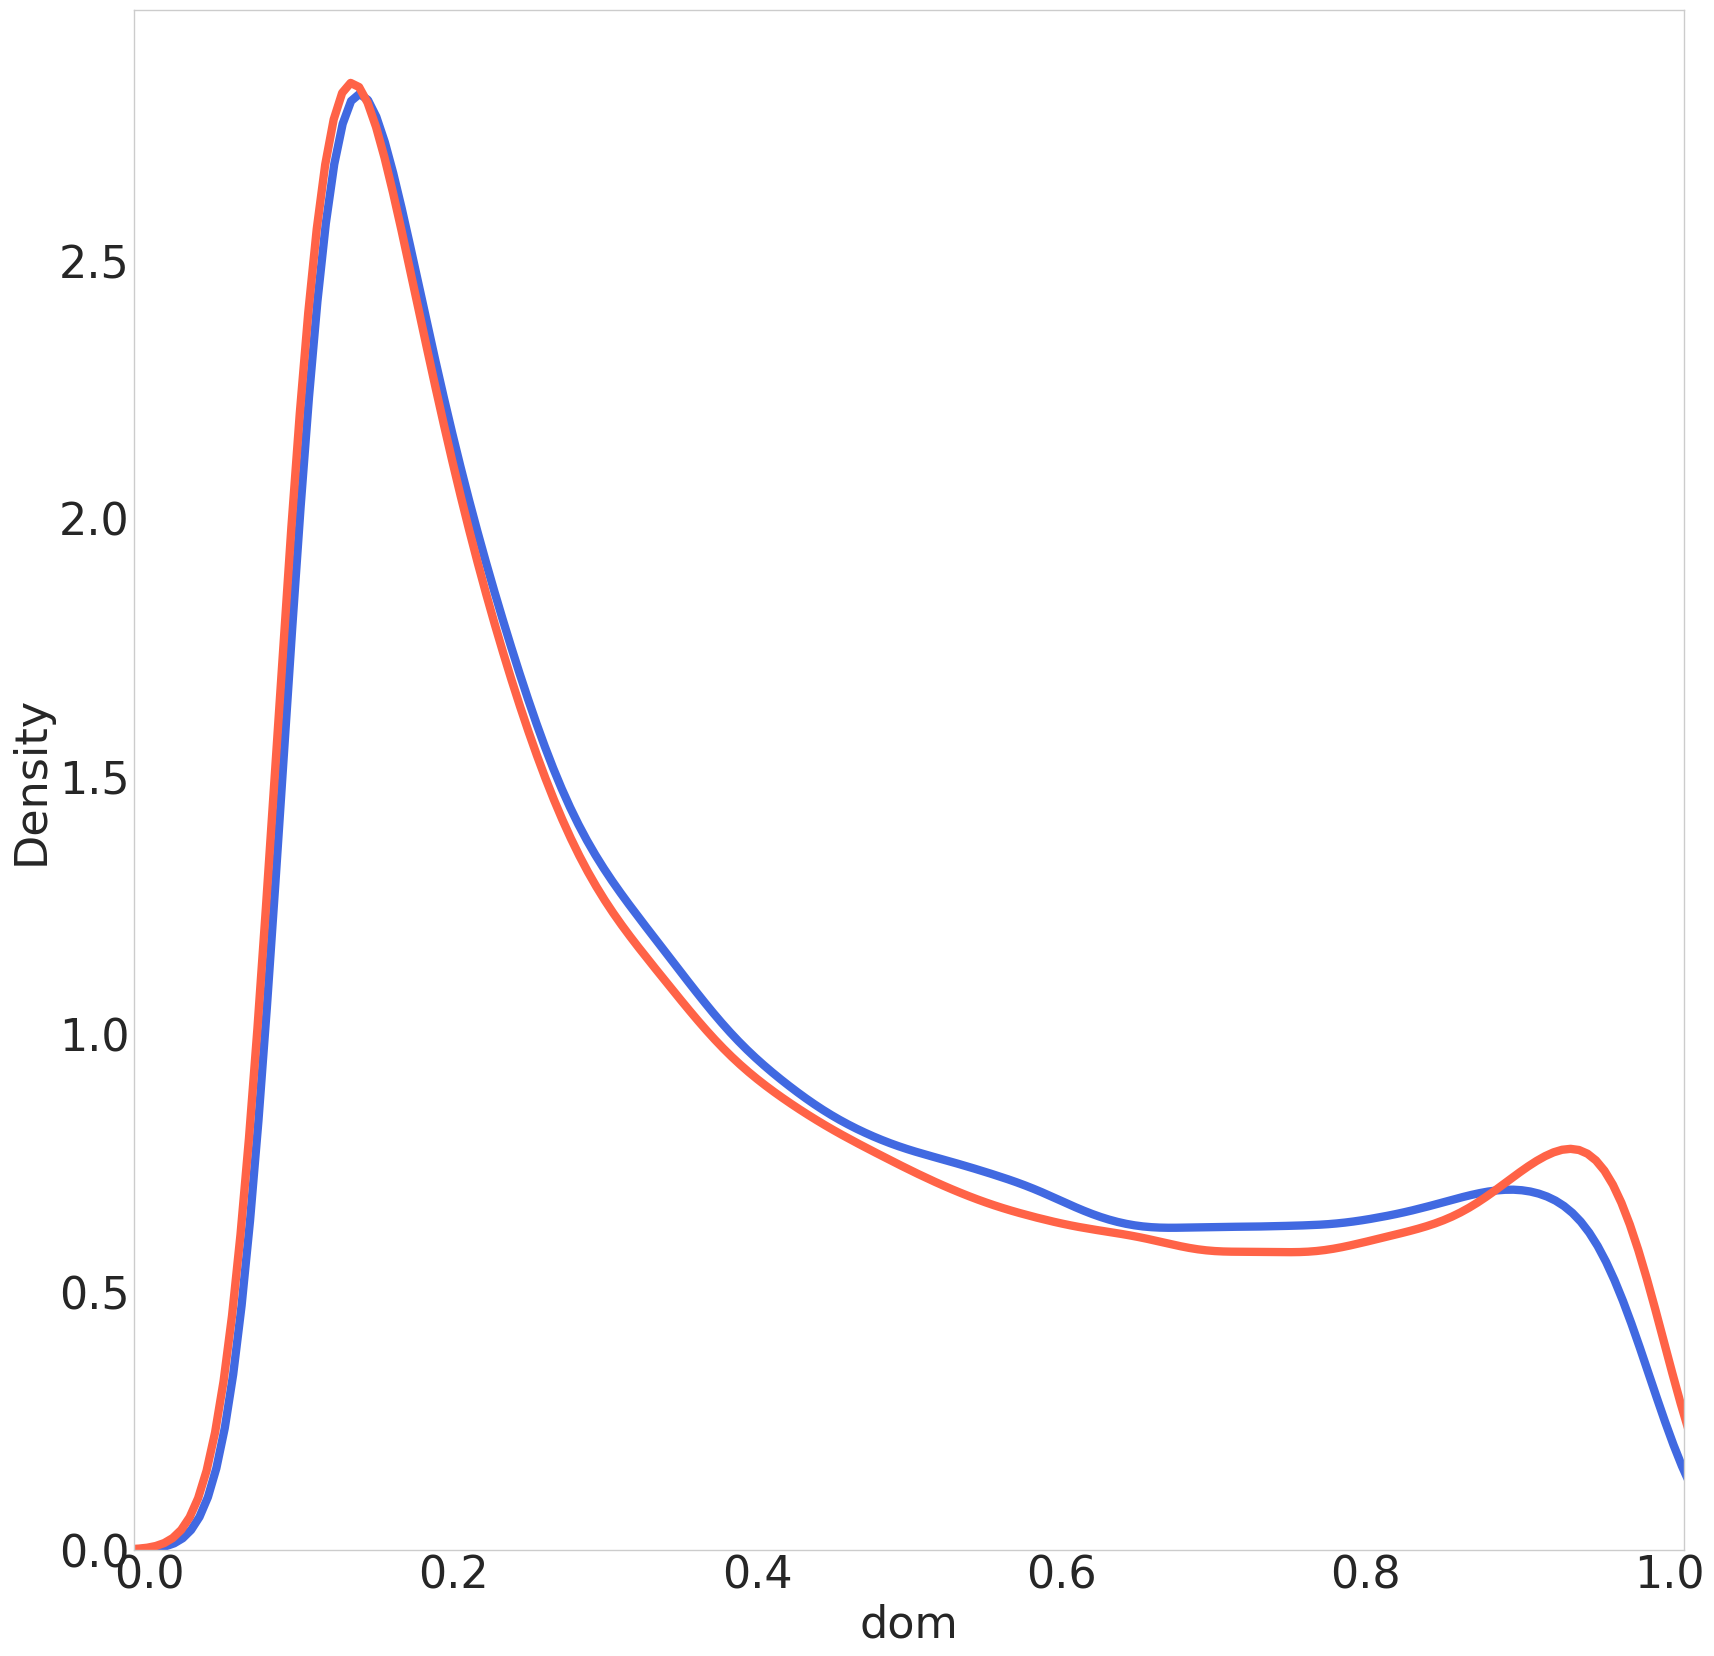

In [38]:
## DOM DISTRIBUTION kde

fig, ax = plt.subplots(1, 1, figsize=(20, 20))

sns.kdeplot(data=hek_eval, x="dom", ax=ax, fill=False, levels=100, color="royalblue", alpha=1.0)
sns.kdeplot(data=hela_eval, x="dom", ax=ax, fill=False, levels=100, color="tomato",  alpha=1.0)

ax.set_xlim(-0.01, 1.01)
ax.grid(False)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/dom_distribution.pdf", format="pdf")
plt.show()

/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


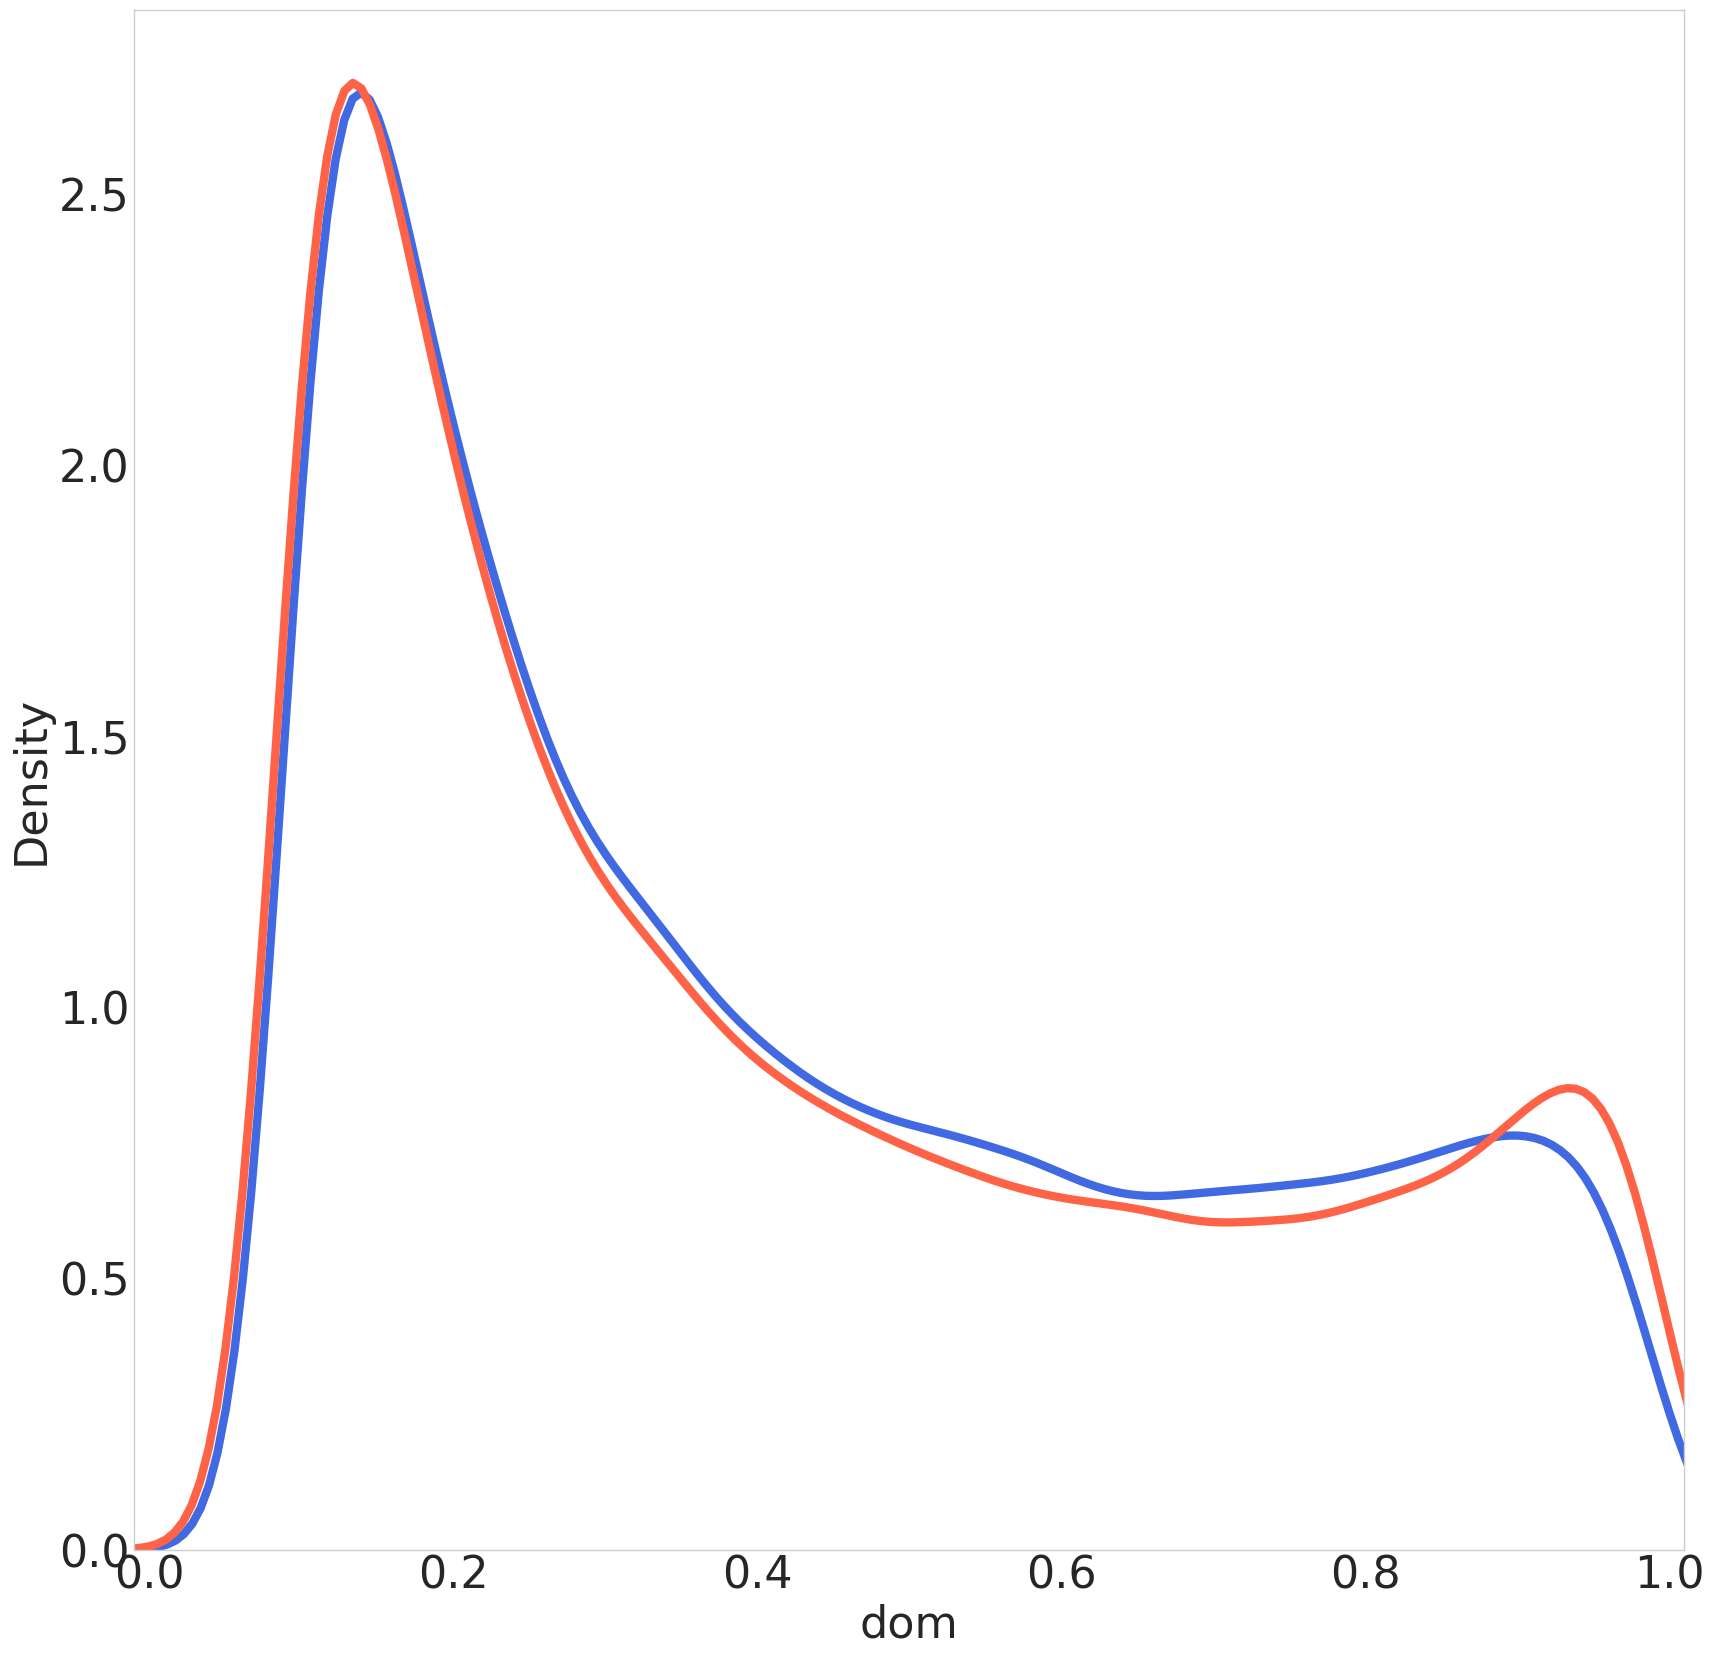

In [39]:
## DOM DISTRIBUTION kde

fig, ax = plt.subplots(1, 1, figsize=(20, 20))

sns.kdeplot(data=hek_eval[hek_eval["drach"]], x="dom", ax=ax, fill=False, levels=100, color="royalblue",  alpha=1.0)
sns.kdeplot(data=hela_eval[hela_eval["drach"]], x="dom", ax=ax, fill=False, levels=100, color="tomato",   alpha=1.0)

ax.set_xlim(-0.01, 1.01)
ax.grid(False)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/dom_drach.pdf", format="pdf")
plt.show()

/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


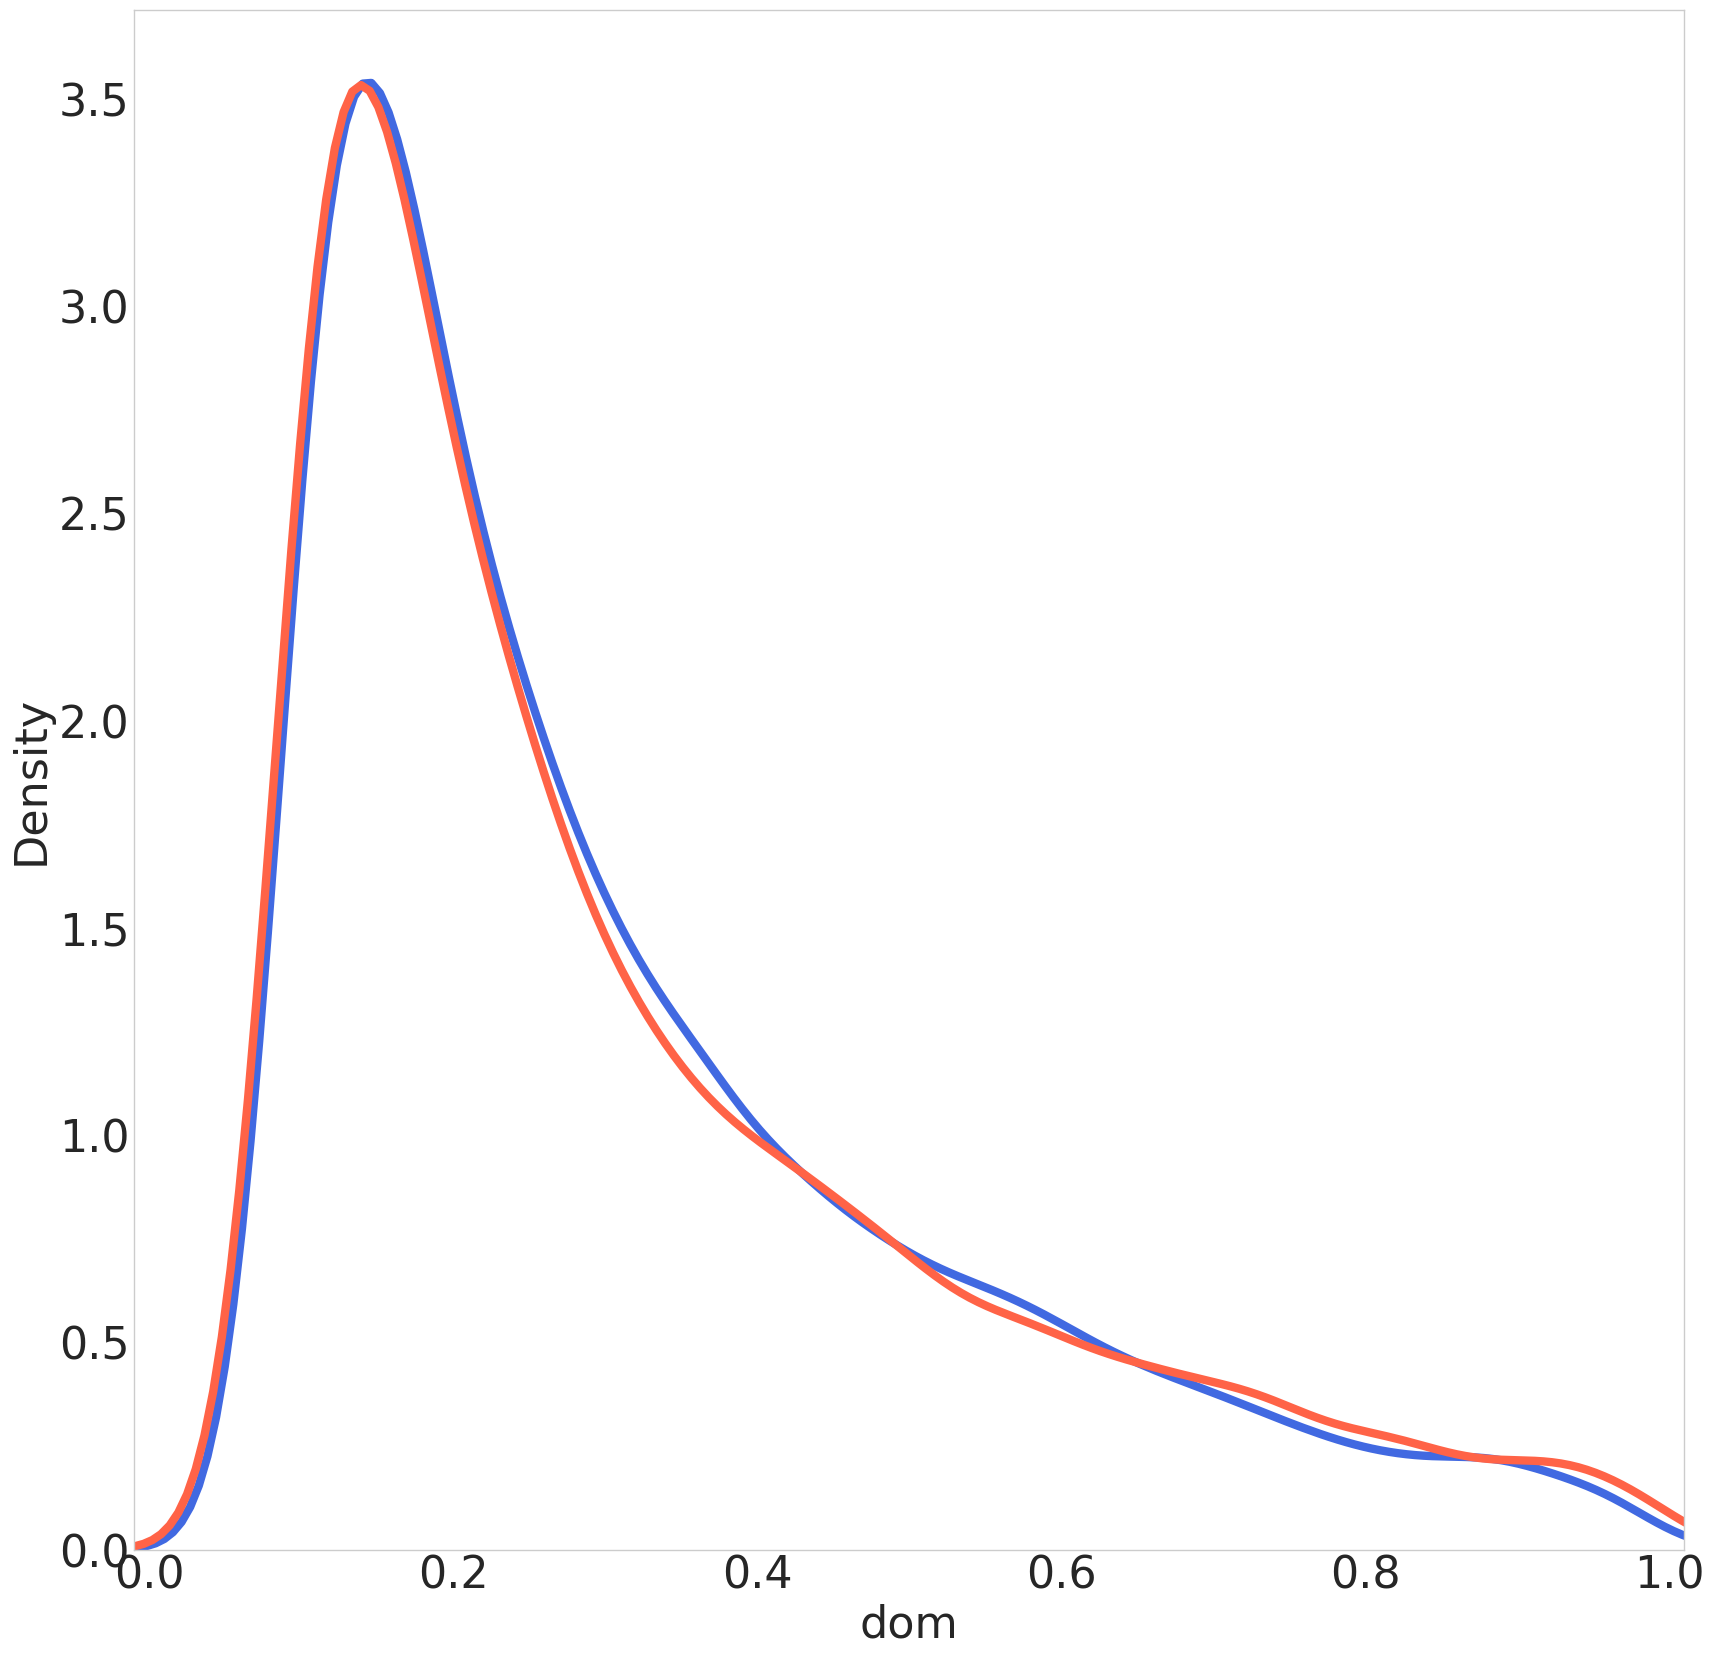

In [40]:
## DOM DISTRIBUTION kde

fig, ax = plt.subplots(1, 1, figsize=(20, 20))

sns.kdeplot(data=hek_eval[~hek_eval["drach"]], x="dom", ax=ax, fill=False, levels=100, color="royalblue",  alpha=1.0)
sns.kdeplot(data=hela_eval[~hela_eval["drach"]], x="dom", ax=ax, fill=False, levels=100, color="tomato",   alpha=1.0)

ax.set_xlim(-0.01, 1.01)
ax.grid(False)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/dom_nondrach.pdf", format="pdf")
plt.show()

In [41]:
hela_m6a_count = hela_genomic_df_m6a.groupby("gene_symbol").size()
hek_m6a_count = hek_genomic_df_m6a.groupby("gene_symbol").size() 

print(hela_m6a_count)
print(hek_m6a_count)

gene_symbol
A4GALT    20
AACS       5
AADAT      7
AAGAB      3
AAK1       9
          ..
ZYG11A    12
ZYG11B     1
ZYX        2
ZZEF1     32
ZZZ3      30
Length: 10236, dtype: int64
gene_symbol
A1BG         1
A1BG-AS1    19
A4GALT      22
AACS         5
AADAT        9
            ..
ZYG11A      14
ZYG11B       6
ZYX          1
ZZEF1       36
ZZZ3        30
Length: 11384, dtype: int64


/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


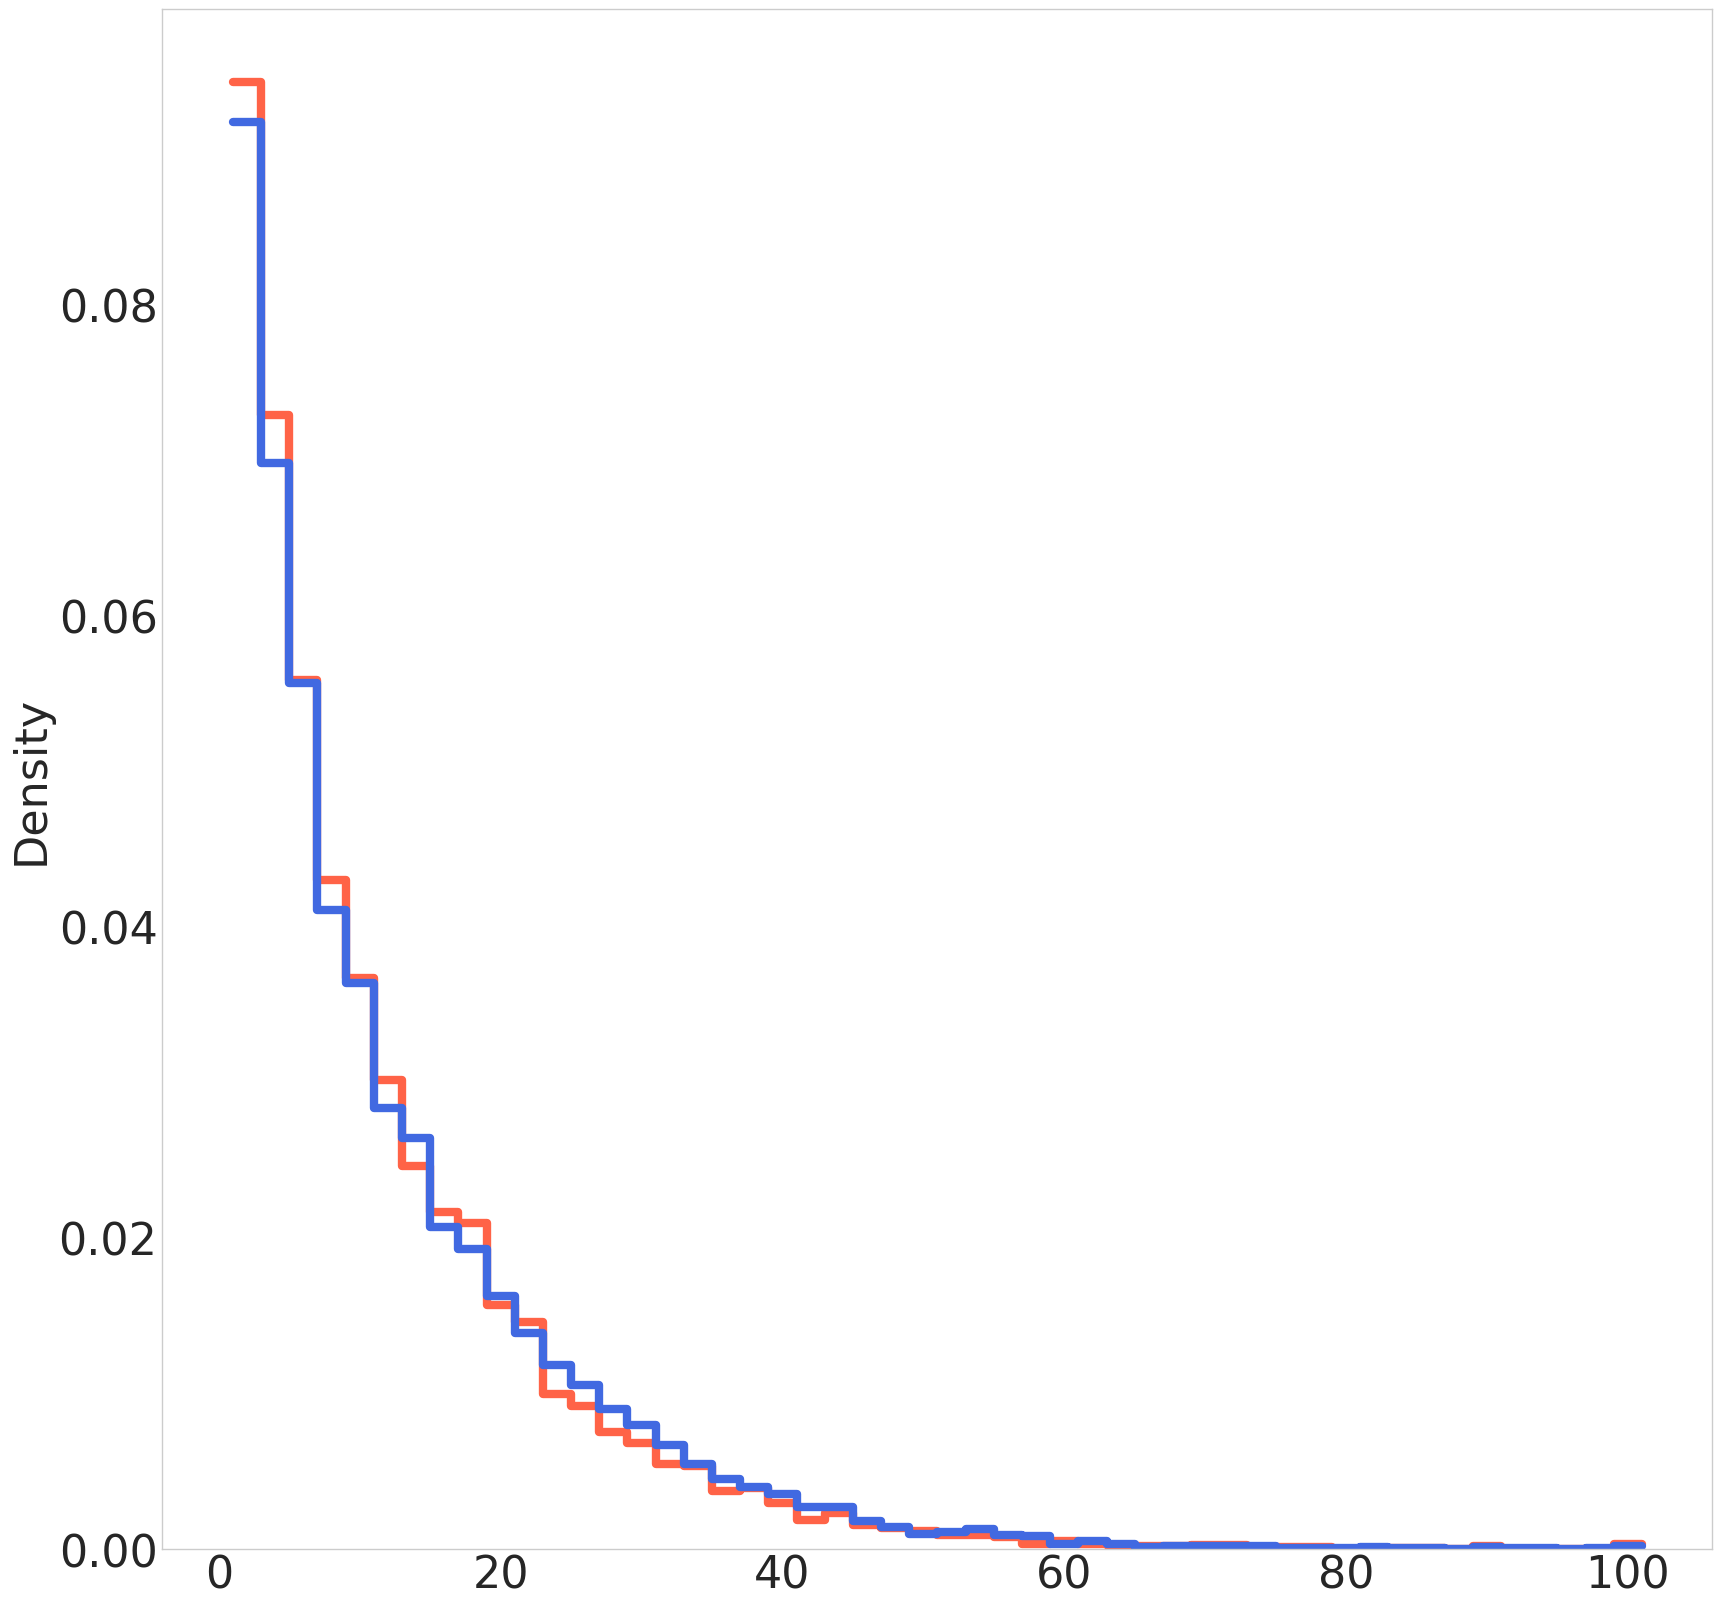

In [42]:
## Plot histogram
fig, ax = plt.subplots(figsize=(20,20))
sns.histplot(np.clip(hela_m6a_count, 0, 100), color="tomato", label="HeLa", element="step", ax=ax, fill=False, binwidth=2, stat="density")
sns.histplot(np.clip(hek_m6a_count,  0, 100), color="royalblue", label="HEK293T", element="step", ax=ax, fill=False, binwidth=2, stat="density")
ax.grid(False)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/density.pdf", format="pdf")
plt.show()

In [43]:
## How many genes have> 30 m6A sites?
print(len(hela_m6a_count[hela_m6a_count > 20])/len(hela_m6a_count))
print(len(hek_m6a_count[hek_m6a_count  > 20])/len(hek_m6a_count))

0.1682297772567409
0.18859803232607167


In [44]:
## How many genes have m6A sites?
print(len(hela_m6a_count[hela_m6a_count > 0])/hela_genomic_df["gene_symbol"].nunique())
print(len(hek_m6a_count[hek_m6a_count > 0])/hek_genomic_df["gene_symbol"].nunique())

0.8670902160101652
0.8637984672585174


In [45]:
## Average number of m6A sites per gene
print(hela_m6a_count.mean())
print(hek_m6a_count.mean())

11.536342321219227
12.08731553056922


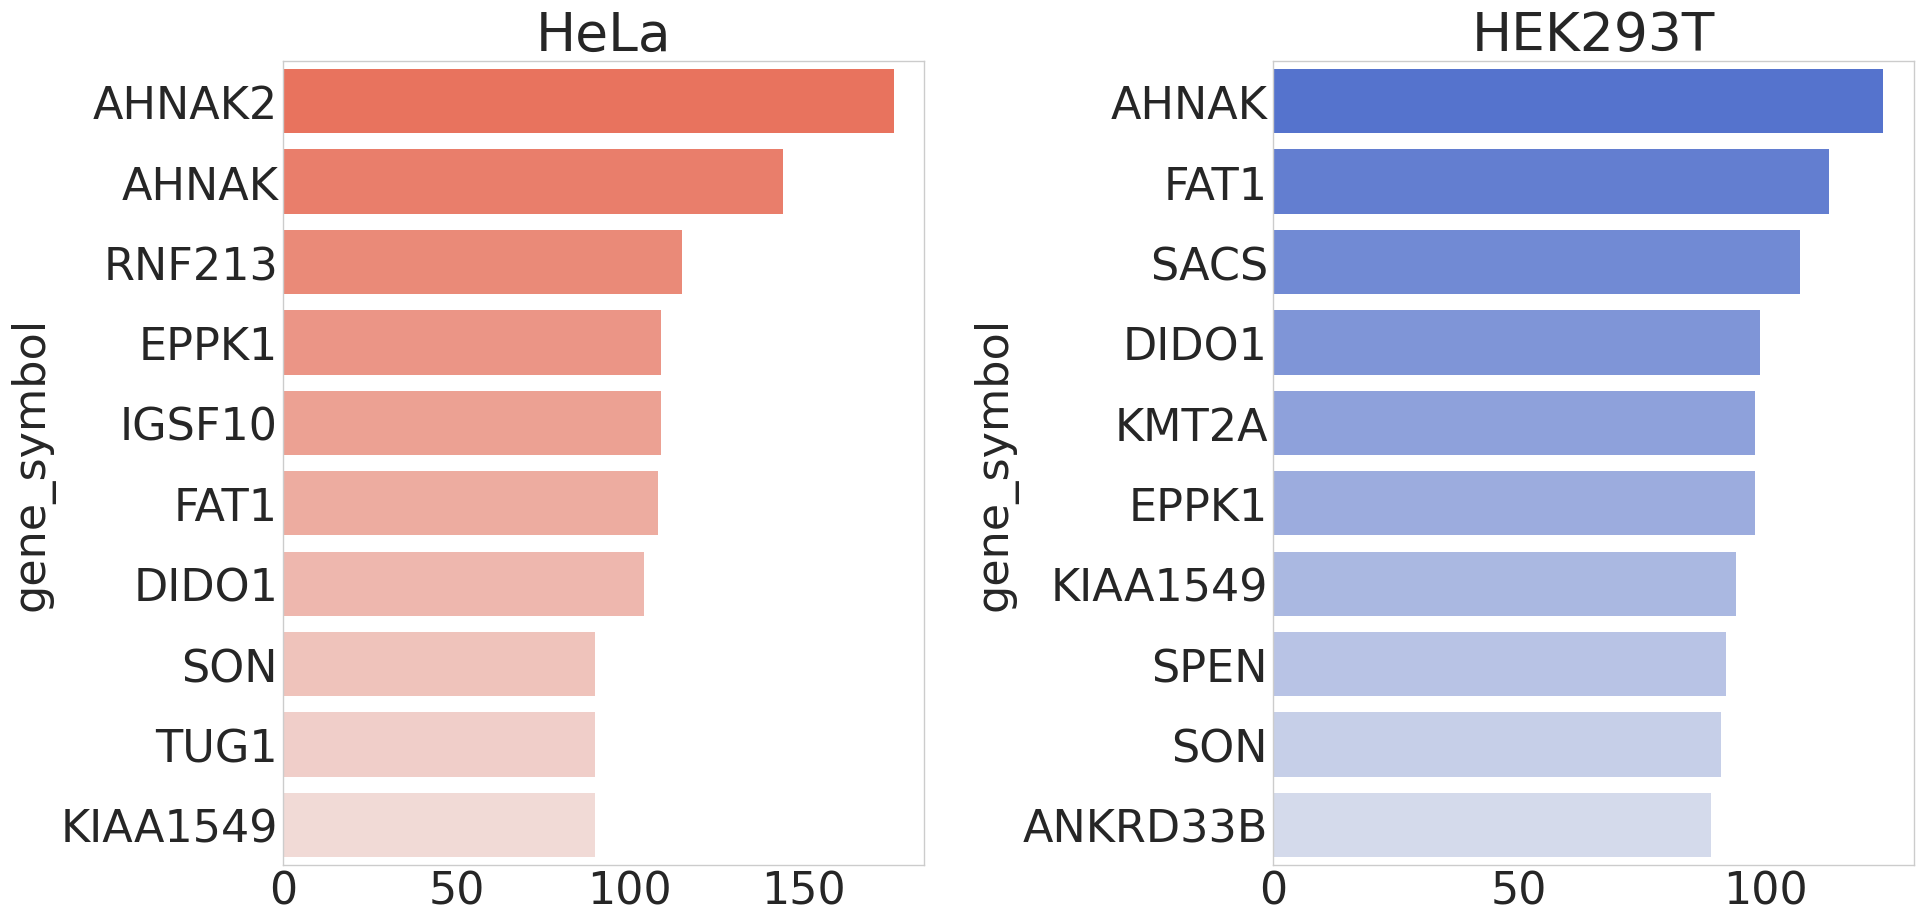

In [46]:
## Plot 10 most heavily m6A modified genes
fig, ax = plt.subplots(1, 2, figsize=(20,10))
hela_arr = hela_m6a_count.sort_values(ascending=False)
hek_arr = hek_m6a_count.sort_values(ascending=False)
## Vertical bar plot
sns.barplot(x=hela_arr[:10], y=hela_arr[:10].index, palette = sns.light_palette("tomato", 12, reverse=True,), ax=ax[0])
sns.barplot(x=hek_arr[:10], y=hek_arr[:10].index, palette = sns.light_palette("royalblue", 12, reverse=True,), ax=ax[1])
ax[0].set_title("HeLa")
ax[1].set_title("HEK293T")
ax[0].grid(False)
ax[1].grid(False)
plt.tight_layout()
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/top10.pdf", format="pdf")
plt.show()

In [47]:
##print top10 genes

print("\n".join(hela_arr[:100].index))
print("")
print("\n".join(hek_arr[:100].index))

AHNAK2
AHNAK
RNF213
EPPK1
IGSF10
FAT1
DIDO1
SON
TUG1
KIAA1549
TBC1D16
ZNF469
MKI67
INF2
PLEC
ZNF646
ZCCHC14
ZBTB38
ARHGAP35
CELSR1
DAG1
SLITRK5
ZNF318
SMCR8
PRECSIT
ERC1
MYORG
IGF1R
MGA
IRS1
ANKRD11
MYOCD
TASOR2
TANC2
FAT4
MPRIP
KCNQ1OT1
SPEN
ASXL1
KIF1B
ZBED4
AHDC1
NRIP1
CHST3
ING5
SRCAP
CELSR3
RANBP6
KLHL5
PHF3
BPTF
PKD1
BCL9L
TSHZ2
ZNF12
CENPF
ARHGAP21
DISP1
PDCD6-AHRR
CELSR2
GLI2
MUC16
ADNP2
MICAL3
TMEM184A
SLITRK4
SYNM
SETD2
SNX29
WDR81
SEC16A
FOXK2
ADCY9
TSHZ1
NSD1
RBM12B
ITPRIP
RAI1
ZNF629
PCDH7
CDK13
RBM15B
TNS3
VCPIP1
SH3PXD2A
SH3BP4
SH3PXD2B
PRAG1
SETD1B
AP5B1
LOC100129034
HS6ST3
C15orf39
MN1
SAMD9
HEG1
ZBED1
NSD2
RBBP6
CAMSAP1

AHNAK
FAT1
SACS
DIDO1
KMT2A
EPPK1
KIAA1549
SPEN
SON
ANKRD33B
TBC1D16
MKI67
ALMS1
H6PD
TUG1
ARHGAP35
ING5
FAT4
PLXNA2
ANKRD11
PEAK1
SMCR8
CELSR2
ERC1
VCAN
SETX
MACF1
TASOR2
ZNF646
PCDH7
LINC00205
MYORG
ZNF318
RESF1
LMTK2
CELSR1
IRS1
IGF1R
BPTF
ZCCHC14
ZBED4
SFMBT2
ZKSCAN2
PTCHD1
MGA
SRCAP
NSD1
PHF3
ZNF618
ZNF778
PCDH9
KAT6A
NRIP1
CHST3
RANBP6
PLEC
HTT


In [48]:
from Bio import SeqIO
ref_path = "/extdata4/baeklab/Hyeonseo/m6A/res/ref/isoform/hg38_rna_nrnm.fasta"
fasta_dict = SeqIO.to_dict(SeqIO.parse(ref_path, "fasta"))
fasta_dict = {x.split(".")[0]: y for x, y in fasta_dict.items()}
a_count_dict = {x: y.seq.count("A") for x, y in fasta_dict.items()}
## Draw Discrepancy
geneid_table = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/res/ref/GRCh38_latest_genomic.convert_table.pkl")
convert_dict = dict(zip(geneid_table["transcript_id"], geneid_table["gene_id"]))
a_count_df = pd.DataFrame(a_count_dict.items(), columns=["refseq", "a_count"])
a_count_df["gene_id"] = a_count_df["refseq"].map(convert_dict)
a_count_df = a_count_df.groupby("gene_id").agg({"a_count": "mean"})


In [51]:
hela_m6a_df = hela_df[hela_df["pm6a"] > fdr_threshold]
hek_m6a_df = hek_df[hek_df["pm6a"] > fdr_threshold]
hela_m6a_df["refseq"] = hela_m6a_df["label_id"].str.split(":").str[0]
hek_m6a_df["refseq"] = hek_m6a_df["label_id"].str.split(":").str[0]
hela_count_df = pd.DataFrame(hela_m6a_df["refseq"].value_counts())
hek_count_df = pd.DataFrame(hek_m6a_df["refseq"].value_counts())

hela_count_df["a_count"] = hela_count_df.index.map(a_count_dict)
hek_count_df["a_count"] = hek_count_df.index.map(a_count_dict)

hela_count_df["density"] = hela_count_df["count"]/hela_count_df["a_count"]
hek_count_df["density"] = hek_count_df["count"]/hek_count_df["a_count"]

hela_count_df["gene_id"] = hela_count_df.index.map(convert_dict)
hek_count_df["gene_id"] = hek_count_df.index.map(convert_dict)

print(hela_count_df)
print(hek_count_df)

/tmp/ipykernel_245313/1680434609.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hela_m6a_df["refseq"] = hela_m6a_df["label_id"].str.split(":").str[0]
/tmp/ipykernel_245313/1680434609.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hek_m6a_df["refseq"] = hek_m6a_df["label_id"].str.split(":").str[0]


              count  a_count   density gene_id
refseq                                        
NM_138420       156     4423  0.035270  AHNAK2
NM_001350929    146     4406  0.033137  AHNAK2
NM_001620       129     5444  0.023696   AHNAK
NM_001346446    128     5446  0.023503   AHNAK
NM_001346445    111     5448  0.020374   AHNAK
...             ...      ...       ...     ...
NM_001102653      1     2083  0.000480   OTUD4
NM_001104631      1     2455  0.000407   PDE4D
NM_152227         1      617  0.001621    SNX5
NM_001320971      1      690  0.001449    LIG1
NM_001320988      1     1242  0.000805  TRIM37

[19551 rows x 4 columns]
              count  a_count   density  gene_id
refseq                                         
NM_005245       113     4184  0.027008     FAT1
NM_001620       100     5444  0.018369    AHNAK
NM_031308        98     2710  0.036162    EPPK1
NM_015001        92     3461  0.026582     SPEN
NM_004285        90     1908  0.047170     H6PD
...             ...      ..

In [52]:
## groupby gene_id, get max density, sort by density
hela_density_df = hela_count_df.groupby("gene_id").agg({"density": "max"}).sort_values("density", ascending=False)
hek_density_df = hek_count_df.groupby("gene_id").agg({"density": "max"}).sort_values("density", ascending=False)

print(hela_density_df)
print(hek_density_df)

          density
gene_id          
ADAT3    0.128713
EXD3     0.123457
MFSD5    0.100000
MC1R     0.093264
LRFN4    0.090439
...           ...
ASXL2    0.000264
SUGT1    0.000244
ARFGEF3  0.000243
HOOK3    0.000230
NBEAL1   0.000193

[9913 rows x 1 columns]
           density
gene_id           
EXD3      0.132716
ADAT3     0.113861
MFSD5     0.100000
MC1R      0.093264
SDHAF1    0.088235
...            ...
ZNF483    0.000247
HOOK3     0.000230
DYNC2H1   0.000226
MRPL42    0.000223
NOPCHAP1  0.000171

[11053 rows x 1 columns]


In [53]:
print(", ".join(hek_density_df.index[:100]))

EXD3, ADAT3, MFSD5, MC1R, SDHAF1, UFSP1, HPS6, LRFN4, PWWP2B, FJX1, C19orf73, OXLD1, SSR4P1, ASH1L-AS1, UQCC4, B3GALT6, RPRML, SCO2, DEXI, CPTP, TMEM121, LARRPM, FAM110A, OXCT2, TIMM29, TMEM177, CCDC85B, TMEM203, NCBP2AS2, KCNJ4, HDHD3, CHST14, CITED4, FAAP20, KTI12, C11orf68, C15orf39, GP1BB, LRFN1, TMEM115, LOC642361, IMP3, LINGO1, FNDC10, DOLK, SLC25A29, MRPS12, ABHD15, ZNF865, KCNG1, BLOC1S4, RNF26, ZNF324B, PLEKHF1, URGCP, KCTD11, LOC101928120, CEBPA-DT, RIOX1, CYBC1, RAB40C, TUSC1, FRAT1, PRRT4, RALY-AS1, SLC66A2, LRRN2, IER3, TICAM1, GFOD2, H2AX, ZNF566-AS1, FBXO46, ZBTB45, RNU6-8, ZNF581, RNU6-7, RTN4R, SAC3D1, CANT1, UBALD1, UCN, WDR6, TMEM74B, MISP3, SLC16A13, ADORA2B, PAQR4, FKRP, BTG3-AS1, LOC100129534, HAPSTR2, FKBPL, TMEM37, TXNDC12, SGSH, B3GALT4, LRFN3, RTN4RL1, C6orf226


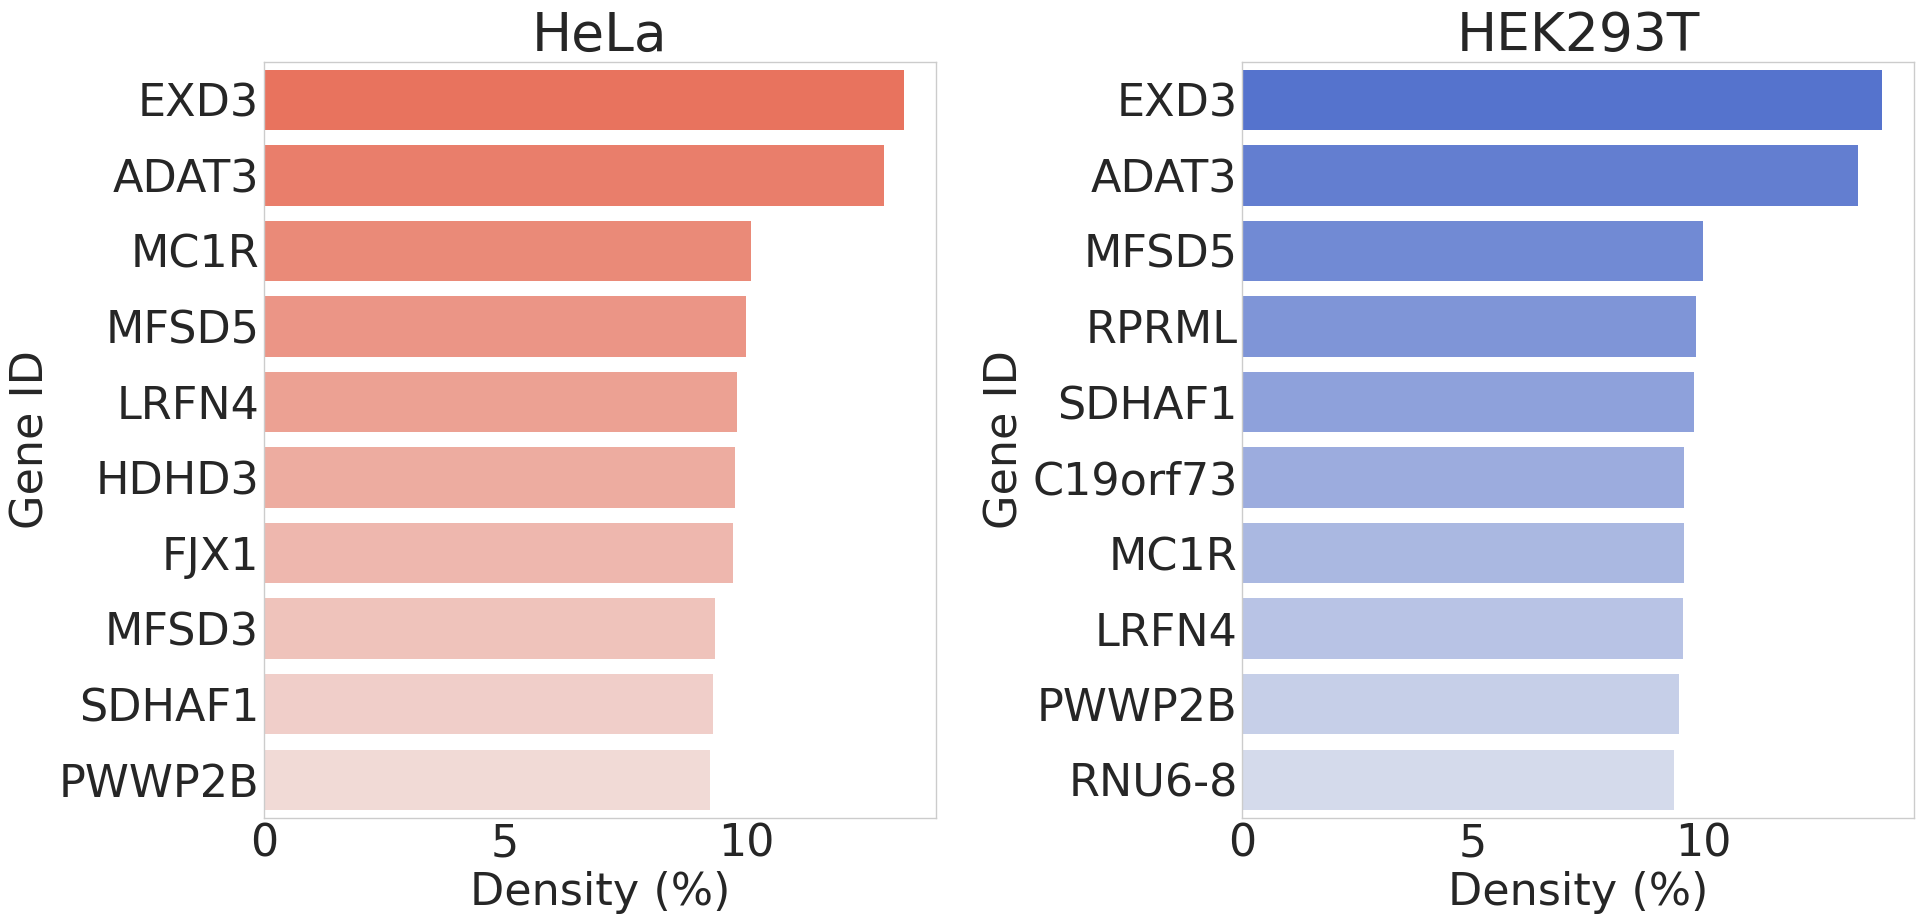

In [118]:
## Plot 10 most heavily m6A modified genes
fig, ax = plt.subplots(1, 2, figsize=(20,10))
## Vertical bar plot
sns.barplot(x=hela_density_df[:10]["density"]*100, y=hela_density_df[:10].index, palette = sns.light_palette("tomato", 12, reverse=True,), ax=ax[0])
sns.barplot(x=hek_density_df[:10]["density"]*100, y=hek_density_df[:10].index, palette = sns.light_palette("royalblue", 12, reverse=True,), ax=ax[1])
ax[0].set_title("HeLa")
ax[1].set_title("HEK293T")
ax[0].grid(False)
ax[1].grid(False)
ax[0].set_xlabel("Density (%)")
ax[1].set_xlabel("Density (%)")
ax[0].set_ylabel("Gene ID")
ax[1].set_ylabel("Gene ID")
plt.tight_layout()
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/top10.pdf", format="pdf")
plt.show()

In [64]:
hek_count_df = hek_df["refseq"].value_counts()
hela_count_df = hela_df["refseq"].value_counts()
hek_start_df = hek_df.groupby("refseq").apply(lambda x: x["pos"].min())
hela_start_df = hela_df.groupby("refseq").apply(lambda x: x["pos"].min())


In [144]:
from Bio import SeqIO
ref_path = "/extdata4/baeklab/Hyeonseo/m6A/res/ref/isoform/hg38_rna_nrnm.fasta"
fasta_dict = SeqIO.to_dict(SeqIO.parse(ref_path, "fasta"))
fasta_dict = {x.split(".")[0]: y for x, y in fasta_dict.items()}


In [146]:
def get_utr_orf_len(exonstarts, exonends, cdsstart, cdsend, strand):

    if exonstarts[0] == cdsstart:
        utr5_len = 0
    else:
        utr5_end_idx = np.argmax(np.array(exonends) > cdsstart)
        utr5_exonstarts = exonstarts[:utr5_end_idx+1].copy()
        utr5_exonends = exonends[:utr5_end_idx+1].copy()
        utr5_exonends[-1] = cdsstart
        utr5_len = sum(np.array(utr5_exonends) - np.array(utr5_exonstarts))

        if utr5_len == 0:
            print(exonstarts, exonends, cdsstart, cdsend, strand)
            raise ValueError("UTR5 length is 0")

    if exonends[-1] == cdsend:
        utr3_len = 0
    else:
        utr3_start_idx = np.argmax(np.array(exonends) >= cdsend)
        utr3_exonstarts = exonstarts[utr3_start_idx:].copy()
        utr3_exonends = exonends[utr3_start_idx:].copy()
        utr3_exonstarts[0] = cdsend
        utr3_len = sum(np.array(utr3_exonends) - np.array(utr3_exonstarts))

        if utr3_len == 0:
            print(exonstarts, exonends, cdsstart, cdsend, strand)
            raise ValueError("UTR5 length is 0")

    if strand == "-":
        utr5_len, utr3_len = utr3_len, utr5_len

    tlen = sum(np.array(exonends) - np.array(exonstarts))
    orf_len = tlen - utr5_len - utr3_len
    return utr5_len, orf_len, utr3_len


In [147]:

refflat_df = utils.parse_refflat()
refflat_df["refseq"] = refflat_df.index
refflat_df.reset_index(inplace=True, drop=True)
refflat_df = refflat_df[refflat_df["refseq"].str.startswith("NM")].copy()
refflat_df[["utr5_len", "orf_len", "utr3_len"]] = refflat_df.apply(lambda x: get_utr_orf_len(x["exonStarts"], x["exonEnds"], x["cdsStart"], x["cdsEnd"], x["strand"]), axis=1, result_type="expand")
refflat_df["tlen"] = refflat_df["refseq"].map(lambda x: len(fasta_dict[x]))


In [149]:

utr_df = refflat_df[refflat_df[['utr5_len', 'orf_len', 'utr3_len']].min(axis=1) > 0].copy()
mean_utr5 = utr_df["utr5_len"].mean()
mean_orf = utr_df["orf_len"].mean()
mean_utr3 = utr_df["utr3_len"].mean()
mean_sum = mean_utr5 + mean_orf + mean_utr3
mean_utr5 /= mean_sum
mean_orf /= mean_sum
mean_utr3 /= mean_sum


In [151]:
def calculate_metagene(utr5_len, orf_len, utr3_len, pos, length_preset = (0.1,0.6,0.3)):
    try:
        bins = [0, utr5_len, utr5_len + orf_len, utr5_len + orf_len + utr3_len]
        length_index = np.digitize(pos, bins) -1
        return (pos - bins[length_index]) / [utr5_len, orf_len, utr3_len][length_index] * length_preset[length_index] + sum(length_preset[:length_index])
    except:
        print(utr5_len, orf_len, utr3_len, pos, length_preset)
        


In [153]:
preset = (mean_utr5, mean_orf, mean_utr3)

In [154]:
hek_m6a_df = hek_df[hek_df["pm6a"] > fdr_threshold]
hek_m6a_df["refseq"] = hek_m6a_df["label_id"].str.split(":").str[0]
hek_m6a_df = hek_m6a_df.merge(refflat_df[['refseq', 'utr5_len', 'orf_len', 'utr3_len']], on="refseq", how="inner")
hek_m6a_df = hek_m6a_df[hek_m6a_df["label_id"].str.startswith("NM")]
hek_m6a_df["pos"] = hek_m6a_df["label_id"].str.split(":").str[1].astype(np.int32)
hek_m6a_df["metagene"] = hek_m6a_df.apply(lambda x: calculate_metagene(x["utr5_len"], x["orf_len"], x["utr3_len"], x["pos"], preset), axis=1)


/tmp/ipykernel_126460/124214823.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hek_m6a_df["refseq"] = hek_m6a_df["label_id"].str.split(":").str[0]


In [157]:
hela_m6a_df = hela_df[hela_df["pm6a"] > fdr_threshold]
hela_m6a_df["refseq"] = hela_m6a_df["label_id"].str.split(":").str[0]
hela_m6a_df = hela_m6a_df.merge(refflat_df[['refseq', 'utr5_len', 'orf_len', 'utr3_len']], on="refseq", how="inner")
hela_m6a_df = hela_m6a_df[hela_m6a_df["label_id"].str.startswith("NM")]
hela_m6a_df["pos"] = hela_m6a_df["label_id"].str.split(":").str[1].astype(np.int32)
hela_m6a_df["metagene"] = hela_m6a_df.apply(lambda x: calculate_metagene(x["utr5_len"], x["orf_len"], x["utr3_len"], x["pos"], preset), axis=1)

/tmp/ipykernel_126460/2224361599.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hela_m6a_df["refseq"] = hela_m6a_df["label_id"].str.split(":").str[0]


53 43746 88 46108 (0.07170213977227484, 0.4453795198334505, 0.4829183403942748)
0 657 3792 4484 (0.07170213977227484, 0.4453795198334505, 0.4829183403942748)


In [162]:
hek_m6a_df = hek_m6a_df.merge(hek_transcript_label[["id", "drach"]], left_on="label_id", right_on="id", how="inner")
hela_m6a_df = hela_m6a_df.merge(hela_transcript_label[["id", "drach"]], left_on="label_id", right_on="id", how="inner")

0.1686866730451584 0.5903514623641968


/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


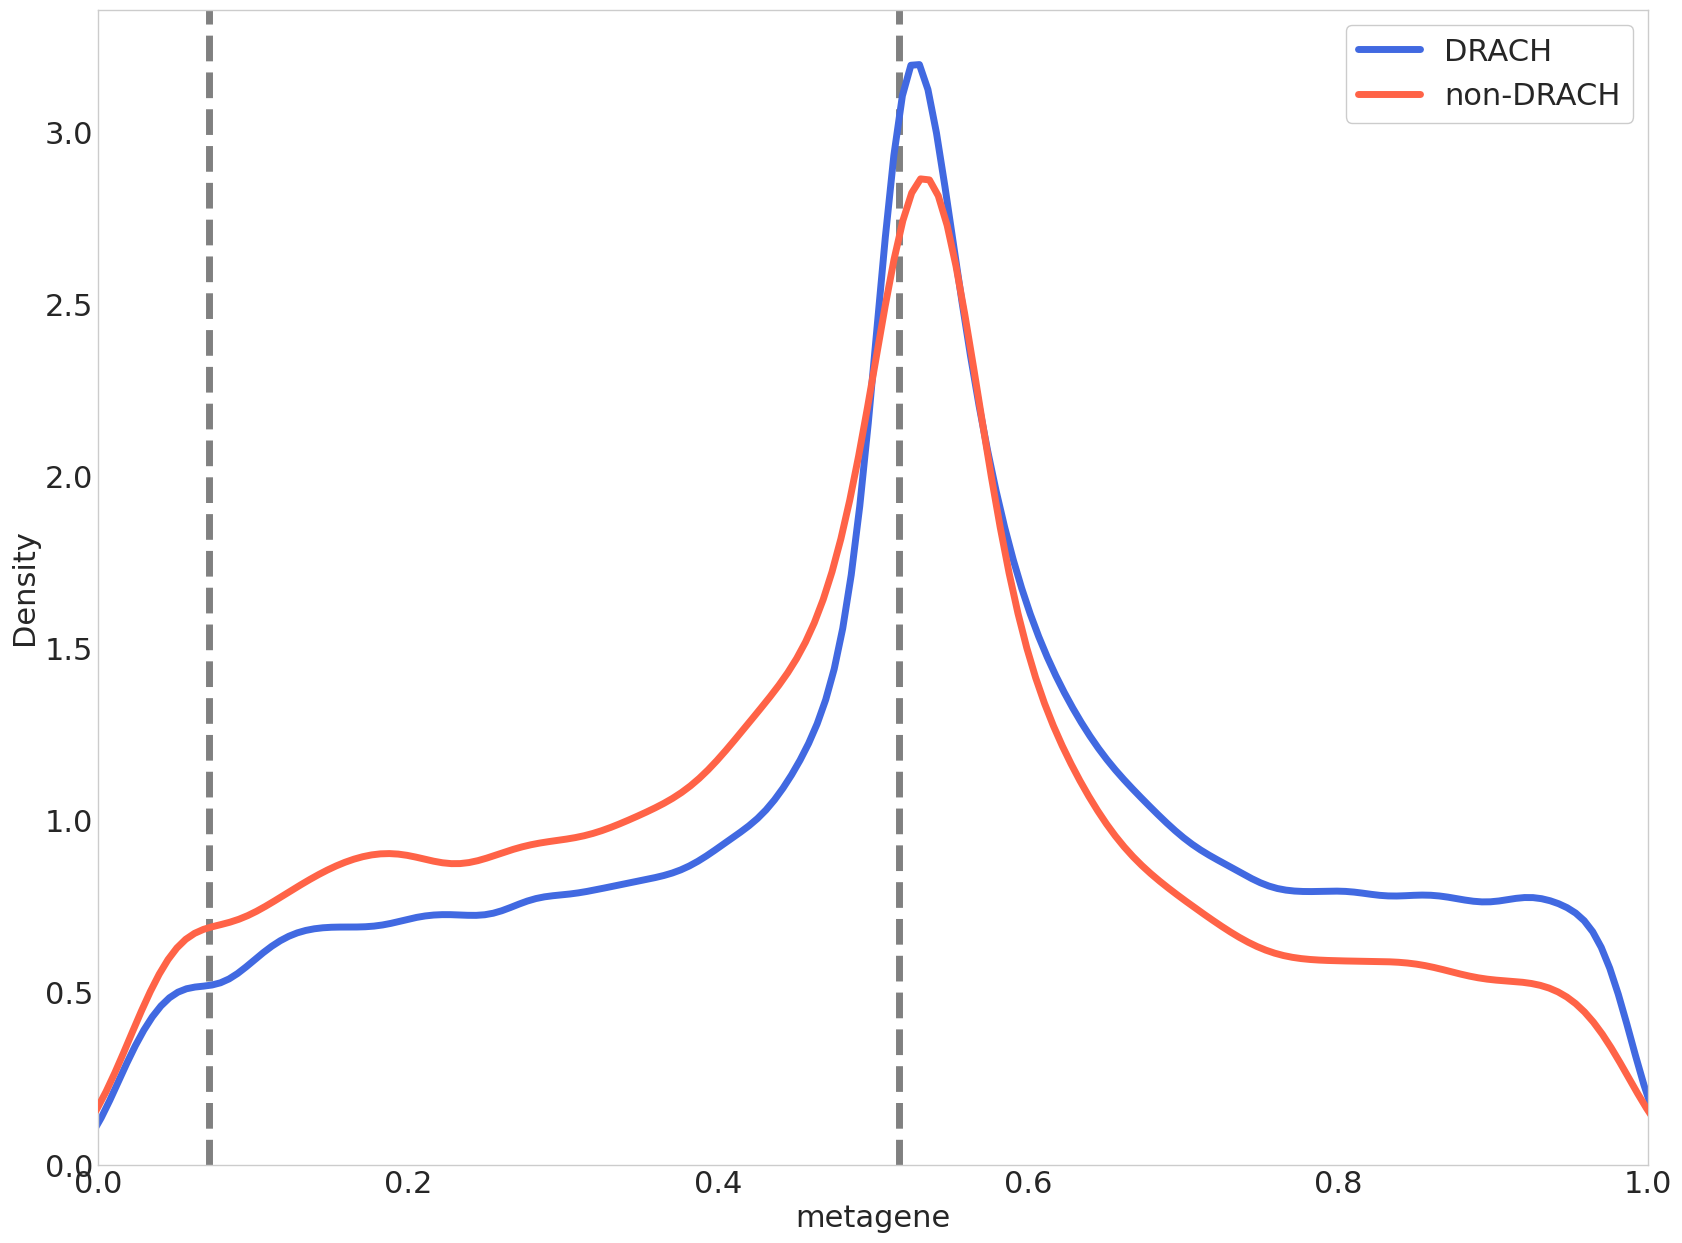

In [165]:
## Draw metagene plot
df = hek_m6a_df
fig, ax = plt.subplots(figsize=(20, 15))

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 5})
## Histogram style without fill.

low_cut = 0.25
high_cut = 0.75

low_cut = df["dom"].quantile(low_cut)
high_cut = df["dom"].quantile(high_cut)

print(low_cut, high_cut)

sns.kdeplot(df[df["drach"]]["metagene"], ax=ax, fill=False, color="royalblue", label="DRACH", zorder=1, bw_adjust=0.75)
sns.kdeplot(df[~df["drach"]]["metagene"], ax=ax, fill=False, color="tomato", label="non-DRACH", zorder=3, bw_adjust=0.75)

for i in range(1, 3):
    ax.axvline(np.array(preset[:i]).sum(), color="grey", linestyle="--", zorder=0)
ax.grid(False)
ax.set_xlim(0, 1)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/metagene_HEK.pdf", format="pdf")
plt.legend()
plt.show()

0.16343500465154648 0.5982391387224197


/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


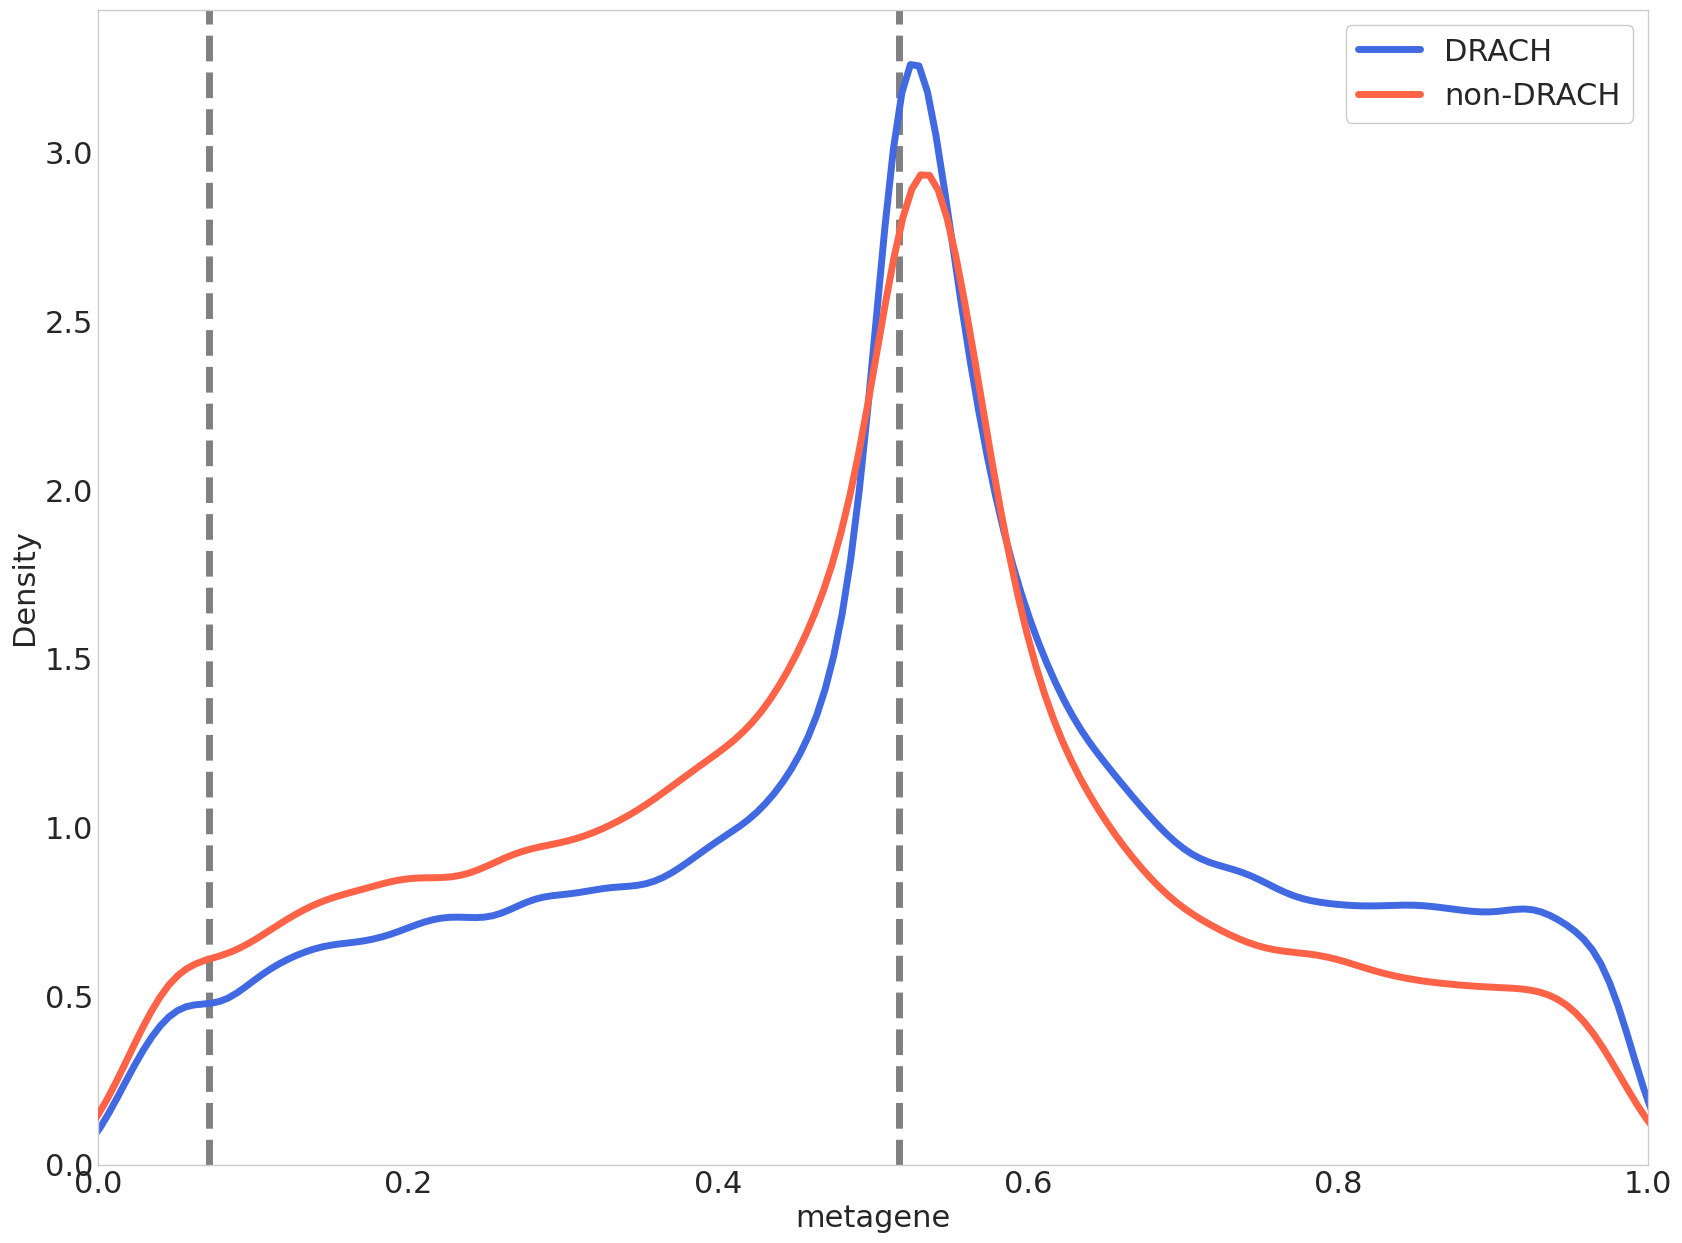

In [164]:
## Draw metagene plot
df = hela_m6a_df
fig, ax = plt.subplots(figsize=(20, 15))

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 5})
## Histogram style without fill.

low_cut = 0.25
high_cut = 0.75

low_cut = df["dom"].quantile(low_cut)
high_cut = df["dom"].quantile(high_cut)

print(low_cut, high_cut)

sns.kdeplot(df[df["drach"]]["metagene"], ax=ax, fill=False, color="royalblue", label="DRACH", zorder=1, bw_adjust=0.75)
sns.kdeplot(df[~df["drach"]]["metagene"], ax=ax, fill=False, color="tomato", label="non-DRACH", zorder=3, bw_adjust=0.75)

for i in range(1, 3):
    ax.axvline(np.array(preset[:i]).sum(), color="grey", linestyle="--", zorder=0)
ax.grid(False)
ax.set_xlim(0, 1)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/metagene_HeLa.pdf", format="pdf")
plt.legend()
plt.show()